In [5]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Dict, List, Optional, Tuple

import numpy as np
from scipy.interpolate import RegularGridInterpolator

# ============================================================
# 1. REGIMES
# ============================================================

REGIMES_D_X_HF = ("D", "X", "HF")


@dataclass(frozen=True)
class RegimeConfig:
    active_modes: Tuple[str, ...] = REGIMES_D_X_HF

    def __post_init__(self) -> None:
        allowed = {"D", "X", "HF"}
        invalid = [m for m in self.active_modes if m not in allowed]
        if invalid:
            raise ValueError(f"Invalid regimes: {invalid}")
        if len(self.active_modes) == 0:
            raise ValueError("Need at least one active regime.")

    @property
    def mode_to_index(self) -> Dict[str, int]:
        return {m: i for i, m in enumerate(self.active_modes)}

    @property
    def index_to_mode(self) -> Dict[int, str]:
        return {i: m for i, m in enumerate(self.active_modes)}
    
# ============================================================
# 2. PARAMETERS
# ============================================================

@dataclass
class ModelParams:
    # Dynamic
    beta: float = 0.95
    delta: float = 0.10

    # Adjustment costs
    phi_H: float = 0.40
    phi_F: float = 0.40

    # Terminal liquidation values
    xi_H: float = 0.40
    xi_F: float = 0.40

    # Marginal investment costs
    q_H: float = 1.0
    q_F: float = 1.0

    # CES / reduced-form parameters
    sigma: float = 5.0
    alpha: float = 0.30

    # Demand / cost shifters
    A_H: float = 1.0
    A_F: float = 1.0
    Lambda_H: float = 1.0
    Lambda_F: float = 1.2
    w_H: float = 1.0
    w_F: float = 1.0
    tau_X: float = 1.15

    # Fixed operating costs
    f_H_op: float = 0.03
    f_X_op: float = 0.015
    f_F_op: float = 0.03

    # Sunk switching costs
    f_X_E: float = 0.10
    f_F_E: float = 0.10
    f_scope: float = 0.05

    eps: float = 1e-10

    @property
    def a(self) -> float:
        return (self.sigma - 1.0) / self.sigma

    @property
    def gamma(self) -> float:
        return 1.0 - self.alpha

    @property
    def mu(self) -> float:
        val = 1.0 - self.a * self.gamma
        if val <= 0:
            raise ValueError("Need mu = 1 - a * gamma > 0.")
        return val

    @property
    def rho(self) -> float:
        return self.a / self.mu

    @property
    def kappa(self) -> float:
        return self.alpha * self.rho

# ============================================================
# 3. PRODUCTIVITY PROCESSES
# ============================================================

def make_constant_productivity_transition(n_s: int) -> np.ndarray:
    """Deterministic productivity process: s_{t+1} = s_t."""
    return np.eye(n_s)


def fixed_s_process(s_value: float) -> Tuple[np.ndarray, np.ndarray]:
    """One-point productivity grid with constant s over time."""
    if s_value <= 0.0:
        raise ValueError("Need s_value > 0.")
    s_grid = np.array([float(s_value)])
    P = make_constant_productivity_transition(1)
    return s_grid, P


def rouwenhorst(
    n: int,
    rho: float,
    sigma_eps: float,
    mu: float = 0.0,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    if n < 2:
        raise ValueError("n must be at least 2.")
    if abs(rho) >= 1.0:
        raise ValueError("Need |rho| < 1 for a stationary AR(1).")

    prob = (1.0 + rho) / 2.0
    P = np.array([[1.0]])

    for m in range(2, n + 1):
        P_new = np.zeros((m, m))
        P_new[:-1, :-1] += prob * P
        P_new[:-1, 1:] += (1.0 - prob) * P
        P_new[1:, :-1] += (1.0 - prob) * P
        P_new[1:, 1:] += prob * P
        P_new[1:-1, :] /= 2.0
        P = P_new

    sigma_z = sigma_eps / np.sqrt(1.0 - rho**2)
    psi = sigma_z * np.sqrt(n - 1)
    z_grid = np.linspace(-psi, psi, n) + mu
    s_grid = np.exp(z_grid)
    return z_grid, s_grid, P


# ============================================================
# 4. TECHNOLOGY, PROFITS, COSTS
# ============================================================

def investment_cost(i: float, phi: float, q: float) -> float:
    return q * i + 0.5 * phi * i**2


def next_capital(K: float, i: float, delta: float) -> float:
    return (1.0 - delta) * K + i


def terminal_value(KH: float, KF: float, p: ModelParams) -> float:
    return p.xi_H * KH + p.xi_F * KF


def switching_cost(prev_mode: str, new_mode: str, p: ModelParams) -> float:
    if prev_mode == new_mode:
        return 0.0

    # D -> X : first export entry
    if prev_mode == "D" and new_mode == "X":
        return p.f_X_E

    # X -> HF : add foreign affiliate
    if prev_mode == "X" and new_mode == "HF":
        return p.f_F_E + p.f_scope

    # D -> HF : become exporter and affiliate at once
    if prev_mode == "D" and new_mode == "HF":
        return p.f_X_E + p.f_F_E + p.f_scope

    # No additional sunk cost on downgrade / exit from HF
    return 0.0


def _safe_power(x: float, power: float, eps: float) -> float:
    return max(x, eps) ** power


def omega_H(p: ModelParams) -> float:
    Rbar_H = p.Lambda_H * ((p.a * p.gamma * p.Lambda_H) / p.w_H) ** (p.a * p.gamma / p.mu)
    return p.mu * Rbar_H * (p.A_H ** p.rho)


def omega_F(p: ModelParams) -> float:
    Rbar_F = p.Lambda_F * ((p.a * p.gamma * p.Lambda_F) / p.w_F) ** (p.a * p.gamma / p.mu)
    return p.mu * Rbar_F * (p.A_F ** p.rho)


def omega_X(p: ModelParams) -> float:
    chi_X = (p.Lambda_F / (p.tau_X * p.Lambda_H)) ** p.sigma
    Xi_X = p.Lambda_H + p.Lambda_F * (chi_X ** p.a)
    w_X_eff = p.w_H * (1.0 + p.tau_X * chi_X) ** (1.0 / p.gamma)
    Rbar_X = Xi_X * ((p.a * p.gamma * Xi_X) / w_X_eff) ** (p.a * p.gamma / p.mu)
    return p.mu * Rbar_X * (p.A_H ** p.rho)


def profit_D(KH: float, s: float, p: ModelParams) -> float:
    return omega_H(p) * _safe_power(KH, p.kappa, p.eps) * (s ** p.rho) - p.f_H_op


def profit_X(KH: float, s: float, p: ModelParams) -> float:
    return omega_X(p) * _safe_power(KH, p.kappa, p.eps) * (s ** p.rho) - p.f_H_op - p.f_X_op


def profit_HF(KH: float, KF: float, s: float, p: ModelParams) -> float:
    home = omega_H(p) * _safe_power(KH, p.kappa, p.eps) * (s ** p.rho)
    foreign = omega_F(p) * _safe_power(KF, p.kappa, p.eps) * (s ** p.rho)
    return home + foreign - p.f_H_op - p.f_F_op


def flow_profit(mode: str, KH: float, KF: float, s: float, p: ModelParams) -> float:
    if mode == "D":
        return profit_D(KH, s, p)
    if mode == "X":
        return profit_X(KH, s, p)
    if mode == "HF":
        return profit_HF(KH, KF, s, p)
    raise ValueError(f"Unknown mode: {mode}")


def mode_allows_foreign_investment(mode: str) -> bool:
    return mode == "HF"

# ============================================================
# 5. INTERPOLATION / EXPECTATIONS
# ============================================================

def _clip(x: float, grid: np.ndarray) -> float:
    return float(np.clip(x, grid[0], grid[-1]))


def nearest_index(grid: np.ndarray, x: float) -> int:
    return int(np.argmin(np.abs(grid - x)))


def local_index_window(center: int, n: int, radius: int) -> np.ndarray:
    lo = max(center - radius, 0)
    hi = min(center + radius, n - 1)
    return np.arange(lo, hi + 1)


def build_value_interpolators(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    V: np.ndarray,
    cfg: RegimeConfig,
) -> Dict[Tuple[str, int], RegularGridInterpolator]:
    interps: Dict[Tuple[str, int], RegularGridInterpolator] = {}

    for pm, prev_mode in enumerate(cfg.active_modes):
        for s_idx in range(len(s_grid)):
            interps[(prev_mode, s_idx)] = RegularGridInterpolator(
                (KH_grid, KF_grid),
                V[pm, :, :, s_idx],
                bounds_error=False,
                fill_value=None,
            )
    return interps


def make_value_callable(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    interps: Dict[Tuple[str, int], RegularGridInterpolator],
) -> Callable[[str, float, float, int], float]:
    def value_obj(prev_mode: str, KH: float, KF: float, s_idx: int) -> float:
        KHc = _clip(KH, KH_grid)
        KFc = _clip(KF, KF_grid)
        return float(interps[(prev_mode, s_idx)](np.array([[KHc, KFc]]))[0])

    return value_obj


def build_expected_grid_from_markov(
    V_next: np.ndarray,
    P: np.ndarray,
    beta: float,
) -> np.ndarray:
    """
    V_next shape:
        (n_prev_mode, n_KH, n_KF, n_s_next)

    Returns:
        EV shape = (n_prev_mode, n_KH, n_KF, n_s_current)
        with EV[..., s_cur] = beta * E[V_next | s_cur]
    """
    n_prev, n_KH, n_KF, _ = V_next.shape
    n_s_cur = P.shape[0]

    EV = np.empty((n_prev, n_KH, n_KF, n_s_cur))
    for pm in range(n_prev):
        for s_cur in range(n_s_cur):
            EV[pm, :, :, s_cur] = beta * np.tensordot(
                V_next[pm, :, :, :],
                P[s_cur, :],
                axes=([2], [0]),
            )
    return EV


def build_expected_interpolators(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    EV: np.ndarray,
    cfg: RegimeConfig,
) -> Dict[Tuple[str, int], RegularGridInterpolator]:
    interps: Dict[Tuple[str, int], RegularGridInterpolator] = {}

    for pm, prev_mode in enumerate(cfg.active_modes):
        for s_idx in range(EV.shape[3]):
            interps[(prev_mode, s_idx)] = RegularGridInterpolator(
                (KH_grid, KF_grid),
                EV[pm, :, :, s_idx],
                bounds_error=False,
                fill_value=None,
            )
    return interps


def make_expected_value_callable(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    interps: Dict[Tuple[str, int], RegularGridInterpolator],
) -> Callable[[str, float, float, int], float]:
    def EV_obj(prev_mode: str, KH: float, KF: float, s_idx: int) -> float:
        KHc = _clip(KH, KH_grid)
        KFc = _clip(KF, KF_grid)
        return float(interps[(prev_mode, s_idx)](np.array([[KHc, KFc]]))[0])

    return EV_obj


# ============================================================
# 6. FAST TERMINAL-PERIOD SOLVER
# ============================================================
from dataclasses import replace

def terminal_investment_kkt(p: ModelParams) -> Tuple[float, float]:
    """
    Last decision period:
        q_H + phi_H * i_H = beta * xi_H
        q_F + phi_F * i_F = beta * xi_F
    with non-negativity constraints.

    Also handles the zero-friction case phi = 0.
    """
    # Home
    if p.phi_H > 0:
        iH = max((p.beta * p.xi_H - p.q_H) / p.phi_H, 0.0)
    else:
        if p.q_H >= p.beta * p.xi_H:
            iH = 0.0
        else:
            raise ValueError(
                "Terminal problem is unbounded for H when phi_H=0 and q_H < beta*xi_H."
            )

    # Foreign
    if p.phi_F > 0:
        iF = max((p.beta * p.xi_F - p.q_F) / p.phi_F, 0.0)
    else:
        if p.q_F >= p.beta * p.xi_F:
            iF = 0.0
        else:
            raise ValueError(
                "Terminal problem is unbounded for F when phi_F=0 and q_F < beta*xi_F."
            )

    return float(iH), float(iF)


def solve_terminal_branch(
    mode: str,
    prev_mode: str,
    KH: float,
    KF: float,
    s: float,
    p: ModelParams,
) -> Dict[str, float]:
    iH, iF = terminal_investment_kkt(p)

    KH_next = next_capital(KH, iH, p.delta)
    KF_next = next_capital(KF, iF, p.delta)

    pi = flow_profit(mode, KH, KF, s, p)
    switch = switching_cost(prev_mode, mode, p)
    adjust = investment_cost(iH, p.phi_H, p.q_H) + investment_cost(iF, p.phi_F, p.q_F)
    cont = p.beta * terminal_value(KH_next, KF_next, p)

    return {
        "mode": mode,
        "value": pi - switch - adjust + cont,
        "profit": pi,
        "switch_cost": switch,
        "iH": iH,
        "iF": iF,
        "KH_next": KH_next,
        "KF_next": KF_next,
        "continuation": cont,
    }


def solve_terminal_period_grid(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
) -> Dict[str, object]:
    n_prev = len(cfg.active_modes)
    n_KH = len(KH_grid)
    n_KF = len(KF_grid)
    n_s = len(s_grid)

    V = np.empty((n_prev, n_KH, n_KF, n_s))
    policy_mode = np.empty((n_prev, n_KH, n_KF, n_s), dtype=int)
    iH_star = np.empty((n_prev, n_KH, n_KF, n_s))
    iF_star = np.empty((n_prev, n_KH, n_KF, n_s))
    KH_next_star = np.empty((n_prev, n_KH, n_KF, n_s))
    KF_next_star = np.empty((n_prev, n_KH, n_KF, n_s))

    for pm, prev_mode in enumerate(cfg.active_modes):
        for i, KH in enumerate(KH_grid):
            for j, KF in enumerate(KF_grid):
                for k, s in enumerate(s_grid):
                    branches = {
                        mode: solve_terminal_branch(
                            mode=mode,
                            prev_mode=prev_mode,
                            KH=KH,
                            KF=KF,
                            s=s,
                            p=p,
                        )
                        for mode in cfg.active_modes
                    }
                    best_mode = max(cfg.active_modes, key=lambda m: branches[m]["value"])
                    best = branches[best_mode]

                    V[pm, i, j, k] = best["value"]
                    policy_mode[pm, i, j, k] = cfg.mode_to_index[best_mode]
                    iH_star[pm, i, j, k] = best["iH"]
                    iF_star[pm, i, j, k] = best["iF"]
                    KH_next_star[pm, i, j, k] = best["KH_next"]
                    KF_next_star[pm, i, j, k] = best["KF_next"]

    interps = build_value_interpolators(KH_grid, KF_grid, s_grid, V, cfg)
    value_obj = make_value_callable(KH_grid, KF_grid, interps)

    return {
        "V": V,
        "policy_mode": policy_mode,
        "iH_star": iH_star,
        "iF_star": iF_star,
        "KH_next_star": KH_next_star,
        "KF_next_star": KF_next_star,
        "interpolators": interps,
        "value_callable": value_obj,
    }

# ============================================================
# 7. FAST PRE-TERMINAL SOLVER
# ============================================================

def solve_branch_local_search(
    mode: str,
    prev_mode: str,
    KH: float,
    KF: float,
    s_idx: int,
    s_grid: np.ndarray,
    EV_obj: Callable[[str, float, float, int], float],
    p: ModelParams,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, float]:
    """
    Fast local search over next-period capital grid points.

    D and X:
      - choose K_H'
      - cannot invest in K_F, so K_F' = (1-delta) K_F

    HF:
      - choose both K_H' and K_F'
    """
    s = float(s_grid[s_idx])

    center_H = nearest_index(KH_grid, (1.0 - p.delta) * KH)
    center_F = nearest_index(KF_grid, (1.0 - p.delta) * KF)

    n_H = len(KH_grid)
    n_F = len(KF_grid)
    visited = set()
    best: Optional[Dict[str, float]] = None

    for _ in range(max_expansions):
        key = (center_H, center_F)
        if key in visited:
            break
        visited.add(key)

        idx_H = local_index_window(center_H, n_H, radius)

        if mode_allows_foreign_investment(mode):
            idx_F = local_index_window(center_F, n_F, radius)
        else:
            idx_F = np.array([center_F])

        best_val = -np.inf
        best_idx: Optional[Tuple[int, int]] = None
        best_local: Optional[Dict[str, float]] = None

        for iH_idx in idx_H:
            KH_next = float(KH_grid[iH_idx])
            iH = KH_next - (1.0 - p.delta) * KH
            if iH < -1e-12:
                continue

            if mode_allows_foreign_investment(mode):
                for iF_idx in idx_F:
                    KF_next = float(KF_grid[iF_idx])
                    iF = KF_next - (1.0 - p.delta) * KF
                    if iF < -1e-12:
                        continue

                    pi = flow_profit(mode, KH, KF, s, p)
                    switch = switching_cost(prev_mode, mode, p)
                    adjust = investment_cost(iH, p.phi_H, p.q_H) + investment_cost(iF, p.phi_F, p.q_F)
                    EV = EV_obj(mode, KH_next, KF_next, s_idx)
                    val = pi - switch - adjust + EV

                    if val > best_val:
                        best_val = val
                        best_idx = (iH_idx, iF_idx)
                        best_local = {
                            "mode": mode,
                            "value": val,
                            "profit": pi,
                            "switch_cost": switch,
                            "iH": float(iH),
                            "iF": float(iF),
                            "KH_next": KH_next,
                            "KF_next": KF_next,
                            "EV": EV,
                        }
            else:
                KF_next = (1.0 - p.delta) * KF
                iF = 0.0

                pi = flow_profit(mode, KH, KF, s, p)
                switch = switching_cost(prev_mode, mode, p)
                adjust = investment_cost(iH, p.phi_H, p.q_H)
                EV = EV_obj(mode, KH_next, KF_next, s_idx)
                val = pi - switch - adjust + EV

                if val > best_val:
                    best_val = val
                    best_idx = (iH_idx, center_F)
                    best_local = {
                        "mode": mode,
                        "value": val,
                        "profit": pi,
                        "switch_cost": switch,
                        "iH": float(iH),
                        "iF": 0.0,
                        "KH_next": KH_next,
                        "KF_next": KF_next,
                        "EV": EV,
                    }

        if best_idx is None or best_local is None:
            raise RuntimeError("Local search failed to find a feasible candidate.")

        best = best_local
        iH_idx, iF_idx = best_idx

        hit_edge_H = ((iH_idx == idx_H[0]) and (iH_idx > 0)) or ((iH_idx == idx_H[-1]) and (iH_idx < n_H - 1))

        if mode_allows_foreign_investment(mode):
            hit_edge_F = ((iF_idx == idx_F[0]) and (iF_idx > 0)) or ((iF_idx == idx_F[-1]) and (iF_idx < n_F - 1))
        else:
            hit_edge_F = False

        if hit_edge_H or hit_edge_F:
            center_H, center_F = iH_idx, iF_idx
            continue

        break

    if best is None:
        raise RuntimeError("Local search terminated without a solution.")

    return best


def solve_nonterminal_period_grid(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    P: np.ndarray,
    next_period_sol: Dict[str, object],
    p: ModelParams,
    cfg: RegimeConfig,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    EV_grid = build_expected_grid_from_markov(
        V_next=next_period_sol["V"],
        P=P,
        beta=p.beta,
    )
    EV_interps = build_expected_interpolators(KH_grid, KF_grid, EV_grid, cfg)
    EV_obj = make_expected_value_callable(KH_grid, KF_grid, EV_interps)

    n_prev = len(cfg.active_modes)
    n_KH = len(KH_grid)
    n_KF = len(KF_grid)
    n_s = len(s_grid)

    V = np.empty((n_prev, n_KH, n_KF, n_s))
    policy_mode = np.empty((n_prev, n_KH, n_KF, n_s), dtype=int)
    iH_star = np.empty((n_prev, n_KH, n_KF, n_s))
    iF_star = np.empty((n_prev, n_KH, n_KF, n_s))
    KH_next_star = np.empty((n_prev, n_KH, n_KF, n_s))
    KF_next_star = np.empty((n_prev, n_KH, n_KF, n_s))

    for pm, prev_mode in enumerate(cfg.active_modes):
        for i, KH in enumerate(KH_grid):
            for j, KF in enumerate(KF_grid):
                for s_idx in range(n_s):
                    branches = {
                        mode: solve_branch_local_search(
                            mode=mode,
                            prev_mode=prev_mode,
                            KH=KH,
                            KF=KF,
                            s_idx=s_idx,
                            s_grid=s_grid,
                            EV_obj=EV_obj,
                            p=p,
                            KH_grid=KH_grid,
                            KF_grid=KF_grid,
                            radius=radius,
                            max_expansions=max_expansions,
                        )
                        for mode in cfg.active_modes
                    }
                    best_mode = max(cfg.active_modes, key=lambda m: branches[m]["value"])
                    best = branches[best_mode]

                    V[pm, i, j, s_idx] = best["value"]
                    policy_mode[pm, i, j, s_idx] = cfg.mode_to_index[best_mode]
                    iH_star[pm, i, j, s_idx] = best["iH"]
                    iF_star[pm, i, j, s_idx] = best["iF"]
                    KH_next_star[pm, i, j, s_idx] = best["KH_next"]
                    KF_next_star[pm, i, j, s_idx] = best["KF_next"]

    interps = build_value_interpolators(KH_grid, KF_grid, s_grid, V, cfg)
    value_obj = make_value_callable(KH_grid, KF_grid, interps)

    return {
        "V": V,
        "policy_mode": policy_mode,
        "iH_star": iH_star,
        "iF_star": iF_star,
        "KH_next_star": KH_next_star,
        "KF_next_star": KF_next_star,
        "interpolators": interps,
        "value_callable": value_obj,
        "expected_grid": EV_grid,
        "expected_interpolators": EV_interps,
        "expected_callable": EV_obj,
    }


# ============================================================
# 8. GENERIC FINITE-HORIZON SOLVER
# ============================================================

def solve_finite_horizon_fast(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    P: np.ndarray,
    n_periods: int,
    p: ModelParams,
    cfg: RegimeConfig,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    """
    Solve a finite-horizon model with n_periods decision periods.

    Timing:
        t = 0, ..., n_periods - 1     : regime and investment choice
        t = n_periods                 : liquidation value only

    The last decision period is solved with the closed-form KKT.
    All earlier periods use the fast expectation-based local search.
    """
    if n_periods < 1:
        raise ValueError("Need n_periods >= 1.")

    period_solutions: List[Optional[Dict[str, object]]] = [None] * n_periods

    period_solutions[-1] = solve_terminal_period_grid(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        s_grid=s_grid,
        p=p,
        cfg=cfg,
    )

    for t in range(n_periods - 2, -1, -1):
        period_solutions[t] = solve_nonterminal_period_grid(
            KH_grid=KH_grid,
            KF_grid=KF_grid,
            s_grid=s_grid,
            P=P,
            next_period_sol=period_solutions[t + 1],
            p=p,
            cfg=cfg,
            radius=radius,
            max_expansions=max_expansions,
        )

    return {
        "KH_grid": KH_grid,
        "KF_grid": KF_grid,
        "s_grid": s_grid,
        "P": P,
        "n_periods": n_periods,
        "p": p,
        "cfg": cfg,
        "period_solutions": period_solutions,
        "solution_t0": period_solutions[0],
    }


# ============================================================
# 9. FIXED-s SOLVER
# ============================================================

def solve_fixed_s_finite_horizon(
    s_value: float,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    n_periods: int,
    p: ModelParams,
    cfg: RegimeConfig,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    s_grid, P = fixed_s_process(s_value)

    bundle = solve_finite_horizon_fast(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        s_grid=s_grid,
        P=P,
        n_periods=n_periods,
        p=p,
        cfg=cfg,
        radius=radius,
        max_expansions=max_expansions,
    )
    bundle["solver_type"] = "fixed_s"
    bundle["s_value"] = float(s_value)
    return bundle


# ============================================================
# 10. STOCHASTIC-s SOLVER
# ============================================================

def solve_stochastic_s_finite_horizon(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    P: np.ndarray,
    n_periods: int,
    p: ModelParams,
    cfg: RegimeConfig,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    bundle = solve_finite_horizon_fast(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        s_grid=s_grid,
        P=P,
        n_periods=n_periods,
        p=p,
        cfg=cfg,
        radius=radius,
        max_expansions=max_expansions,
    )
    bundle["solver_type"] = "stochastic_s"
    return bundle


def solve_rouwenhorst_finite_horizon(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    n_periods: int,
    p: ModelParams,
    cfg: RegimeConfig,
    n_s: int = 11,
    rho: float = 0.90,
    sigma_eps: float = 0.12,
    mu: float = 0.0,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    z_grid, s_grid, P = rouwenhorst(n=n_s, rho=rho, sigma_eps=sigma_eps, mu=mu)

    bundle = solve_stochastic_s_finite_horizon(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        s_grid=s_grid,
        P=P,
        n_periods=n_periods,
        p=p,
        cfg=cfg,
        radius=radius,
        max_expansions=max_expansions,
    )
    bundle["z_grid"] = z_grid
    return bundle


# ============================================================
# 11. POLICY SIMULATION
# ============================================================

def simulate_one_path(
    model_bundle: Dict[str, object],
    KH0: float,
    KF0: float,
    s0_idx: int,
    initial_prev_mode: str = "X",
    stochastic: bool = True,
    seed: Optional[int] = None,
) -> Dict[str, object]:
    KH_grid = model_bundle["KH_grid"]
    KF_grid = model_bundle["KF_grid"]
    s_grid = model_bundle["s_grid"]
    P = model_bundle["P"]
    cfg = model_bundle["cfg"]
    n_periods = model_bundle["n_periods"]
    period_solutions = model_bundle["period_solutions"]

    rng = np.random.default_rng(seed)

    KH_path = [float(KH0)]
    KF_path = [float(KF0)]
    s_idx_path = [int(s0_idx)]
    s_path = [float(s_grid[s0_idx])]
    mode_path: List[str] = []
    iH_path: List[float] = []
    iF_path: List[float] = []

    prev_mode = initial_prev_mode

    for t in range(n_periods):
        sol_t = period_solutions[t]

        i = nearest_index(KH_grid, KH_path[-1])
        j = nearest_index(KF_grid, KF_path[-1])
        k = s_idx_path[-1]
        pm = cfg.mode_to_index[prev_mode]

        mode = cfg.index_to_mode[int(sol_t["policy_mode"][pm, i, j, k])]
        iH = float(sol_t["iH_star"][pm, i, j, k])
        iF = float(sol_t["iF_star"][pm, i, j, k])
        KH_next = float(sol_t["KH_next_star"][pm, i, j, k])
        KF_next = float(sol_t["KF_next_star"][pm, i, j, k])

        mode_path.append(mode)
        iH_path.append(iH)
        iF_path.append(iF)
        KH_path.append(KH_next)
        KF_path.append(KF_next)

        if t < n_periods - 1:
            if stochastic:
                k_next = int(rng.choice(np.arange(len(s_grid)), p=P[k, :]))
            else:
                k_next = k
            s_idx_path.append(k_next)
            s_path.append(float(s_grid[k_next]))

        prev_mode = mode

    return {
        "KH_path": KH_path,
        "KF_path": KF_path,
        "s_idx_path": s_idx_path,
        "s_path": s_path,
        "mode_path": mode_path,
        "iH_path": iH_path,
        "iF_path": iF_path,
    }


def simulate_many_paths(
    model_bundle: Dict[str, object],
    KH0: float,
    KF0: float,
    s0_idx: int,
    n_firms: int = 100,
    initial_prev_mode: str = "X",
    stochastic: bool = True,
    seed: int = 123,
) -> List[Dict[str, object]]:
    rng = np.random.default_rng(seed)
    seeds = rng.integers(0, 2**32 - 1, size=n_firms)

    return [
        simulate_one_path(
            model_bundle=model_bundle,
            KH0=KH0,
            KF0=KF0,
            s0_idx=s0_idx,
            initial_prev_mode=initial_prev_mode,
            stochastic=stochastic,
            seed=int(seeds[i]),
        )
        for i in range(n_firms)
    ]


# ============================================================
# 12. SMALL PRINTER
# ============================================================

def print_path_summary(path: Dict[str, object], label: str = "path") -> None:
    print(f"\\n=== {label} ===")
    print("modes:   ", path["mode_path"])
    print("iH path: ", [round(x, 4) for x in path["iH_path"]])
    print("iF path: ", [round(x, 4) for x in path["iF_path"]])
    print("KH path: ", [round(x, 4) for x in path["KH_path"]])
    print("KF path: ", [round(x, 4) for x in path["KF_path"]])
    print("s path:  ", [round(x, 4) for x in path["s_path"]])

In [6]:
cfg = RegimeConfig(active_modes=("X", "HF", "D"))
p = ModelParams()

KH_grid = np.linspace(0.10, 4.0, 40)
KF_grid = np.linspace(0.00, 2.0, 20)

# Fixed-s version
model_fixed = solve_fixed_s_finite_horizon(
    s_value=1.0,
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    n_periods=3,
    p=p,
    cfg=cfg,
)

In [24]:
# Stochastic version D,X,HF
z_grid, s_grid, P = rouwenhorst(n=11, rho=0.9, sigma_eps=0.12)

cfg = RegimeConfig(active_modes=("D", "X", "HF"))

model_stoch_DXHF = solve_stochastic_s_finite_horizon(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid,
    P=P,
    n_periods=9,
    p=p,
    cfg=cfg,
)

from dataclasses import replace


1. For 11 prod states

    a.  $50 \times 50$ states takes 32 minutes to solve 

    b. $40 \times 20$ takes 6 minutes

2. For 19 prod states. 

    b. $40 \times 20$ takes 12 minutes


In [128]:
# No-friction version
p_no_fric = replace(p, phi_H=0.0, phi_F=0.0)

model_stoch_no_fric = solve_stochastic_s_finite_horizon(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid,
    P=P,
    n_periods=9,
    p=p_no_fric,
    cfg=cfg,
)

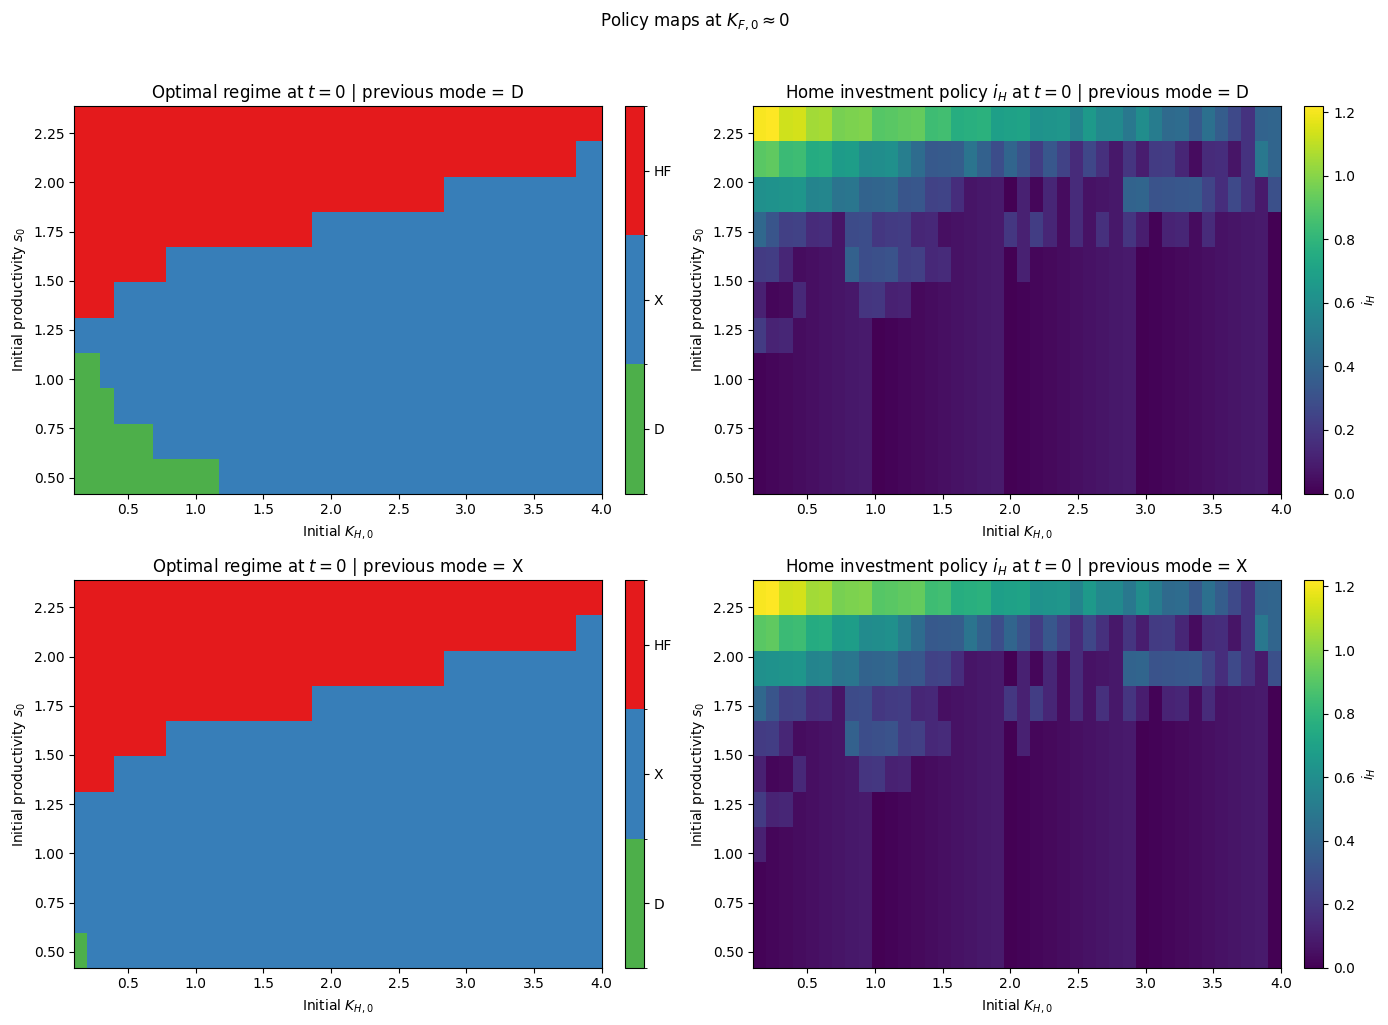

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

def plot_policy_maps_DX_at_KF0(
    model_bundle: Dict[str, object],
    KF0_target: float = 0.0,
) -> None:
    """
    Plot t=0 policy maps at a fixed KF0 slice (typically KF0 = 0) for:
      - prev_mode = D
      - prev_mode = X

    For each current mode, show:
      1. optimal next regime
      2. home investment policy i_H

    State space on each panel:
      x-axis = initial KH
      y-axis = initial productivity s
    """
    KH_grid = model_bundle["KH_grid"]
    KF_grid = model_bundle["KF_grid"]
    s_grid = model_bundle["s_grid"]
    cfg = model_bundle["cfg"]
    sol_t0 = model_bundle["solution_t0"]

    required_modes = {"D", "X", "HF"}
    missing = required_modes.difference(cfg.active_modes)
    if missing:
        raise ValueError(f"Need active modes D, X, HF. Missing: {missing}")

    j0 = nearest_index(KF_grid, KF0_target)

    pm_D = cfg.mode_to_index["D"]
    pm_X = cfg.mode_to_index["X"]

    # Shapes in sol_t0 arrays: (prev_mode, KH, KF, s)
    # For plotting, transpose to (s, KH)
    regime_D = sol_t0["policy_mode"][pm_D, :, j0, :].T
    regime_X = sol_t0["policy_mode"][pm_X, :, j0, :].T

    iH_D = sol_t0["iH_star"][pm_D, :, j0, :].T
    iH_X = sol_t0["iH_star"][pm_X, :, j0, :].T

    # Regime colormap in the order of cfg.active_modes
    mode_colors = []
    for m in cfg.active_modes:
        if m == "D":
            mode_colors.append("#4daf4a")  # green
        elif m == "X":
            mode_colors.append("#377eb8")  # blue
        elif m == "HF":
            mode_colors.append("#e41a1c")  # red
        else:
            mode_colors.append("#999999")

    regime_cmap = ListedColormap(mode_colors)
    regime_norm = BoundaryNorm(np.arange(len(cfg.active_modes) + 1) - 0.5, regime_cmap.N)

    extent = [KH_grid.min(), KH_grid.max(), s_grid.min(), s_grid.max()]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # -----------------------------
    # Row 1: prev_mode = D
    # -----------------------------
    im_reg_D = axes[0, 0].imshow(
        regime_D,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=regime_cmap,
        norm=regime_norm,
    )
    axes[0, 0].set_xlabel(r"Initial $K_{H,0}$")
    axes[0, 0].set_ylabel(r"Initial productivity $s_0$")
    axes[0, 0].set_title(r"Optimal regime at $t=0$ | previous mode = D")

    cbar_reg_D = fig.colorbar(
        im_reg_D,
        ax=axes[0, 0],
        ticks=np.arange(len(cfg.active_modes)),
        fraction=0.046,
        pad=0.04,
    )
    cbar_reg_D.ax.set_yticklabels(list(cfg.active_modes))

    im_iH_D = axes[0, 1].imshow(
        iH_D,
        origin="lower",
        aspect="auto",
        extent=extent,
    )
    axes[0, 1].set_xlabel(r"Initial $K_{H,0}$")
    axes[0, 1].set_ylabel(r"Initial productivity $s_0$")
    axes[0, 1].set_title(r"Home investment policy $i_H$ at $t=0$ | previous mode = D")
    fig.colorbar(im_iH_D, ax=axes[0, 1], fraction=0.046, pad=0.04, label=r"$i_H$")

    # -----------------------------
    # Row 2: prev_mode = X
    # -----------------------------
    im_reg_X = axes[1, 0].imshow(
        regime_X,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=regime_cmap,
        norm=regime_norm,
    )
    axes[1, 0].set_xlabel(r"Initial $K_{H,0}$")
    axes[1, 0].set_ylabel(r"Initial productivity $s_0$")
    axes[1, 0].set_title(r"Optimal regime at $t=0$ | previous mode = X")

    cbar_reg_X = fig.colorbar(
        im_reg_X,
        ax=axes[1, 0],
        ticks=np.arange(len(cfg.active_modes)),
        fraction=0.046,
        pad=0.04,
    )
    cbar_reg_X.ax.set_yticklabels(list(cfg.active_modes))

    im_iH_X = axes[1, 1].imshow(
        iH_X,
        origin="lower",
        aspect="auto",
        extent=extent,
    )
    axes[1, 1].set_xlabel(r"Initial $K_{H,0}$")
    axes[1, 1].set_ylabel(r"Initial productivity $s_0$")
    axes[1, 1].set_title(r"Home investment policy $i_H$ at $t=0$ | previous mode = X")
    fig.colorbar(im_iH_X, ax=axes[1, 1], fraction=0.046, pad=0.04, label=r"$i_H$")

    fig.suptitle(r"Policy maps at $K_{F,0}\approx 0$", y=1.02)
    plt.tight_layout()
    plt.show()


# Run:
plot_policy_maps_DX_at_KF0(
    model_bundle=model_stoch_DXHF,
    KF0_target=0.0,
)

# Analysis 

### Step 1: Build inital exporter (X) and domestic (D) set 

In [26]:
import numpy as np
import pandas as pd

def classify_initial_states_by_value(
    model_bundle: Dict[str, object],
    KF0_target: float = 0.0,
    initial_prev_mode: str = "D",
    kh_step: int = 1,
    s_idx_subset: Optional[list[int]] = None,
    radius: int = 7,
    max_expansions: int = 5,
) -> pd.DataFrame:
    """
    Classify initial states on a fixed KF0 slice by comparing
    W0^D, W0^X, W0^HF directly.

    Returns one row per state with:
      - W0_D, W0_X, W0_HF
      - best_mode
      - value gaps
    """
    KH_grid = model_bundle["KH_grid"]
    KF_grid = model_bundle["KF_grid"]
    s_grid = model_bundle["s_grid"]
    p = model_bundle["p"]
    cfg = model_bundle["cfg"]
    sol_t0 = model_bundle["solution_t0"]

    if s_idx_subset is None:
        s_idx_subset = list(range(len(s_grid)))

    if "expected_callable" not in sol_t0:
        raise ValueError(
            "solution_t0 does not contain 'expected_callable'. "
            "This classifier assumes at least 2 decision periods."
        )

    EV1_obj = sol_t0["expected_callable"]
    j0 = nearest_index(KF_grid, KF0_target)

    required_modes = {"D", "X", "HF"}
    missing = required_modes.difference(cfg.active_modes)
    if missing:
        raise ValueError(f"Need active modes D, X, HF. Missing: {missing}")

    rows = []

    for s_idx in s_idx_subset:
        for i in range(0, len(KH_grid), kh_step):
            KH0 = float(KH_grid[i])
            KF0 = float(KF_grid[j0])
            s0 = float(s_grid[s_idx])

            branch_D = solve_branch_local_search(
                mode="D",
                prev_mode=initial_prev_mode,
                KH=KH0,
                KF=KF0,
                s_idx=s_idx,
                s_grid=s_grid,
                EV_obj=EV1_obj,
                p=p,
                KH_grid=KH_grid,
                KF_grid=KF_grid,
                radius=radius,
                max_expansions=max_expansions,
            )

            branch_X = solve_branch_local_search(
                mode="X",
                prev_mode=initial_prev_mode,
                KH=KH0,
                KF=KF0,
                s_idx=s_idx,
                s_grid=s_grid,
                EV_obj=EV1_obj,
                p=p,
                KH_grid=KH_grid,
                KF_grid=KF_grid,
                radius=radius,
                max_expansions=max_expansions,
            )

            branch_HF = solve_branch_local_search(
                mode="HF",
                prev_mode=initial_prev_mode,
                KH=KH0,
                KF=KF0,
                s_idx=s_idx,
                s_grid=s_grid,
                EV_obj=EV1_obj,
                p=p,
                KH_grid=KH_grid,
                KF_grid=KF_grid,
                radius=radius,
                max_expansions=max_expansions,
            )

            W0_D = float(branch_D["value"])
            W0_X = float(branch_X["value"])
            W0_HF = float(branch_HF["value"])

            branch_vals = {"D": W0_D, "X": W0_X, "HF": W0_HF}
            best_mode = max(branch_vals, key=branch_vals.get)

            rows.append({
                "state_id": len(rows),
                "KH0": KH0,
                "KF0": KF0,
                "s0_idx": int(s_idx),
                "s0": s0,

                "W0_D": W0_D,
                "W0_X": W0_X,
                "W0_HF": W0_HF,
                "best_mode": best_mode,

                "gap_X_minus_D": W0_X - W0_D,
                "gap_HF_minus_X": W0_HF - W0_X,
                "gap_HF_minus_D": W0_HF - W0_D,

                "pi_D": flow_profit("D", KH0, KF0, s0, p),
                "pi_X": flow_profit("X", KH0, KF0, s0, p),
                "pi_HF": flow_profit("HF", KH0, KF0, s0, p),
            })

    df = pd.DataFrame(rows)
    return df.sort_values(["s0_idx", "KH0"]).reset_index(drop=True)

def collect_initial_mode_set(
    classified_df: pd.DataFrame,
    target_mode: str,
) -> pd.DataFrame:
    """
    Extract the set of initial states classified into target_mode.
    """
    out = classified_df.loc[classified_df["best_mode"] == target_mode].copy()
    return out.reset_index(drop=True)

##### Exporter set

In [27]:

classified_from_X = classify_initial_states_by_value(
    model_bundle=model_stoch_DXHF,
    KF0_target=0.0,
    initial_prev_mode="X",
    kh_step=1,
)

domestic_set_from_X = collect_initial_mode_set(classified_from_X, "D")
exporter_set_from_X = collect_initial_mode_set(classified_from_X, "X")
hf_set_from_X = collect_initial_mode_set(classified_from_X, "HF")

print("From prev_mode = X")
print("Domestic set size:", len(domestic_set_from_X))
print("Exporter set size:", len(exporter_set_from_X))
print("HF set size:", len(hf_set_from_X))

From prev_mode = X
Domestic set size: 1
Exporter set size: 305
HF set size: 134


##### Domestic set

In [28]:
classified_from_D = classify_initial_states_by_value(
    model_bundle=model_stoch_DXHF,
    KF0_target=0.0,
    initial_prev_mode="D",
    kh_step=1,
)

domestic_set = collect_initial_mode_set(classified_from_D, "D")
exporter_set = collect_initial_mode_set(classified_from_D, "X")
hf_set = collect_initial_mode_set(classified_from_D, "HF")

print("From prev_mode = D")
print("Domestic set size:", len(domestic_set))
print("Exporter set size:", len(exporter_set))
print("HF set size:", len(hf_set))

From prev_mode = D
Domestic set size: 22
Exporter set size: 284
HF set size: 134


### Step 2: Simulate many shock path from each inital state

In [29]:
def simulate_from_initial_state_grid(
    model_bundle: Dict[str, object],
    initial_states: pd.DataFrame,
    N: int = 300,
    stochastic: bool = True,
    initial_prev_mode: str = "X",
    seed: int = 123,
) -> list[dict]:
    """
    For each initial state in `initial_states`, simulate N firms forward.
    """
    out = []

    for row_idx, row in initial_states.iterrows():
        state_seed = seed + 10000 * row_idx

        paths = simulate_many_paths(
            model_bundle=model_bundle,
            KH0=float(row["KH0"]),
            KF0=float(row["KF0"]),
            s0_idx=int(row["s0_idx"]),
            n_firms=N,
            initial_prev_mode=initial_prev_mode,
            stochastic=stochastic,
            seed=state_seed,
        )

        rec = {
            "state_id": int(row["state_id"]),
            "KH0": float(row["KH0"]),
            "KF0": float(row["KF0"]),
            "s0_idx": int(row["s0_idx"]),
            "s0": float(row["s0"]),
            "paths": paths,
        }

        # keep any useful classification columns if present
        for col in ["best_mode", "W0_D", "W0_X", "W0_HF", "pi_D", "pi_X", "pi_HF"]:
            if col in row.index:
                rec[col] = row[col]

        out.append(rec)

    return out

In [30]:
sim_D = simulate_from_initial_state_grid(
    model_bundle=model_stoch_DXHF,
    initial_states=domestic_set,
    N=300,
    stochastic=True,
    initial_prev_mode="D",
    seed=123,
)
sim_D_to_X = simulate_from_initial_state_grid(
    model_bundle=model_stoch_DXHF,
    initial_states= exporter_set,
    N=300,
    stochastic=True,
    initial_prev_mode="D",
    seed=456,
)

sim_X = simulate_from_initial_state_grid(
    model_bundle=model_stoch_DXHF,
    initial_states=exporter_set_from_X,
    N=300,
    stochastic=True,
    initial_prev_mode="X",
    seed=789,
)

### Step 3 
for each path, record: 
1. First period when HF is entered
2. Whether ever entered HF
3. Final regime
4. Paths of K_H and K_F

The first block has one row per simulated firm path. The second has one row per firm period

In [31]:
import numpy as np
import pandas as pd

import numpy as np
import pandas as pd

def _first_entry_period(
    mode_path: list[str],
    target_mode: str,
    initial_prev_mode: str,
) -> float:
    """
    First period t in which the firm enters target_mode:
      mode_t = target_mode and previous mode != target_mode.
    Returns np.nan if target_mode is never entered.
    """
    for t, m in enumerate(mode_path):
        prev_m = initial_prev_mode if t == 0 else mode_path[t - 1]
        if (m == target_mode) and (prev_m != target_mode):
            return float(t)
    return np.nan

def simulation_grid_to_summary_df(
    sim_grid: list[dict],
    initial_prev_mode: str = "X",
) -> pd.DataFrame:
    """
    One row per simulated firm-path.

    Records:
      - first entry into D / X / HF
      - whether each regime is ever visited
      - whether any switch ever occurs
      - final regime
      - full KH / KF / mode paths
    """
    rows = []

    for state in sim_grid:
        for firm_id, path in enumerate(state["paths"]):
            mode_path = path["mode_path"]

            first_d = _first_entry_period(mode_path, "D", initial_prev_mode)
            first_x = _first_entry_period(mode_path, "X", initial_prev_mode)
            first_hf = _first_entry_period(mode_path, "HF", initial_prev_mode)

            ever_d = int(any(m == "D" for m in mode_path))
            ever_x = int(any(m == "X" for m in mode_path))
            ever_hf = int(any(m == "HF" for m in mode_path))

            ever_switch = int(any(
                (mode_path[t] != (initial_prev_mode if t == 0 else mode_path[t - 1]))
                for t in range(len(mode_path))
            ))

            final_mode = mode_path[-1]

            row = {
                "state_id": state["state_id"],
                "firm_id": firm_id,

                "KH0": state["KH0"],
                "KF0": state["KF0"],
                "s0_idx": state["s0_idx"],
                "s0": state["s0"],

                "initial_prev_mode": initial_prev_mode,

                "first_d_period": first_d,
                "first_x_period": first_x,
                "first_hf_period": first_hf,

                "ever_d": ever_d,
                "ever_x": ever_x,
                "ever_hf": ever_hf,
                "ever_switch": ever_switch,

                "final_mode": final_mode,
                "final_is_d": int(final_mode == "D"),
                "final_is_x": int(final_mode == "X"),
                "final_is_hf": int(final_mode == "HF"),

                "KH_path": list(path["KH_path"]),
                "KF_path": list(path["KF_path"]),
                "mode_path": list(path["mode_path"]),
                "s_path": list(path["s_path"]),
                "iH_path": list(path["iH_path"]),
                "iF_path": list(path["iF_path"]),

                "KH_final": float(path["KH_path"][-1]),
                "KF_final": float(path["KF_path"][-1]),
            }

            for col in ["best_mode", "W0_D", "W0_X", "W0_HF", "pi_D", "pi_X", "pi_HF"]:
                if col in state:
                    row[col] = state[col]

            rows.append(row)

    return pd.DataFrame(rows)

def simulation_grid_to_long_df(
    sim_grid: list[dict],
    initial_prev_mode: str = "X",
) -> pd.DataFrame:
    """
    One row per firm-period.
    Includes regime indicators and entry indicators.
    """
    rows = []

    for state in sim_grid:
        for firm_id, path in enumerate(state["paths"]):
            n_periods = len(path["mode_path"])

            for t in range(n_periods):
                prev_m = initial_prev_mode if t == 0 else path["mode_path"][t - 1]
                mode_t = path["mode_path"][t]

                row = {
                    "state_id": state["state_id"],
                    "firm_id": firm_id,
                    "t": t,

                    "KH0": state["KH0"],
                    "KF0": state["KF0"],
                    "s0_idx": state["s0_idx"],
                    "s0": state["s0"],

                    "initial_prev_mode": initial_prev_mode,
                    "prev_mode_t": prev_m,
                    "mode_t": mode_t,

                    "is_d_t": int(mode_t == "D"),
                    "is_x_t": int(mode_t == "X"),
                    "is_hf_t": int(mode_t == "HF"),

                    "switch_t": int(mode_t != prev_m),
                    "enter_d_t": int((mode_t == "D") and (prev_m != "D")),
                    "enter_x_t": int((mode_t == "X") and (prev_m != "X")),
                    "enter_hf_t": int((mode_t == "HF") and (prev_m != "HF")),

                    "s_t": float(path["s_path"][t]),
                    "KH_t": float(path["KH_path"][t]),
                    "KF_t": float(path["KF_path"][t]),
                    "iH_t": float(path["iH_path"][t]),
                    "iF_t": float(path["iF_path"][t]),
                    "KH_tp1": float(path["KH_path"][t + 1]),
                    "KF_tp1": float(path["KF_path"][t + 1]),
                }

                for col in ["best_mode", "W0_D", "W0_X", "W0_HF", "pi_D", "pi_X", "pi_HF"]:
                    if col in state:
                        row[col] = state[col]

                rows.append(row)

    return pd.DataFrame(rows)


In [32]:
summary_df_D = simulation_grid_to_summary_df(sim_D, initial_prev_mode="D")
long_df_D = simulation_grid_to_long_df(sim_D, initial_prev_mode="D")

summary_df_X = simulation_grid_to_summary_df(sim_X, initial_prev_mode="X")
long_df_X = simulation_grid_to_long_df(sim_X, initial_prev_mode="X")

### Step 4: Aggregate
For each $(s_0,K_0)$ compute 

1. HF-entry probability
2. median entry time 
3. probability of remaining in X 
4. average investment path



In [33]:
import numpy as np
import pandas as pd

def add_stay_in_mode_flags(summary_df: pd.DataFrame) -> pd.DataFrame:
    """
    Add indicators for staying in D / X / HF for the entire simulated path.
    Assumes summary_df contains a column 'mode_path'.
    """
    out = summary_df.copy()

    out["stay_d_all_periods"] = out["mode_path"].apply(lambda mp: int(all(m == "D" for m in mp)))
    out["stay_x_all_periods"] = out["mode_path"].apply(lambda mp: int(all(m == "X" for m in mp)))
    out["stay_hf_all_periods"] = out["mode_path"].apply(lambda mp: int(all(m == "HF" for m in mp)))

    return out

def aggregate_simulations_by_initial_state(summary_df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate simulated outcomes by initial state.

    Returns one row per initial state with:
      - share ever switching
      - share ever entering D / X / HF
      - final shares in D / X / HF
      - first-entry timing
    """
    needed_cols = [
        "state_id", "s0_idx", "s0", "KH0", "KF0", "firm_id",
        "ever_switch", "ever_d", "ever_x", "ever_hf",
        "first_d_period", "first_x_period", "first_hf_period",
        "final_is_d", "final_is_x", "final_is_hf",
        "KH_final", "KF_final"
    ]
    missing = [c for c in needed_cols if c not in summary_df.columns]
    if missing:
        raise ValueError(f"summary_df is missing required columns: {missing}")

    agg = (
        summary_df
        .groupby(["state_id", "s0_idx", "s0", "KH0", "KF0"], as_index=False)
        .agg(
            n_paths=("firm_id", "count"),

            # switching / ever-visited shares
            switch_share=("ever_switch", "mean"),
            ever_d_share=("ever_d", "mean"),
            ever_x_share=("ever_x", "mean"),
            ever_hf_share=("ever_hf", "mean"),

            # timing
            mean_first_d_period=("first_d_period", "mean"),
            median_first_d_period=("first_d_period", "median"),
            mean_first_x_period=("first_x_period", "mean"),
            median_first_x_period=("first_x_period", "median"),
            mean_first_hf_period=("first_hf_period", "mean"),
            median_first_hf_period=("first_hf_period", "median"),

            # final regime shares
            final_d_share=("final_is_d", "mean"),
            final_x_share=("final_is_x", "mean"),
            final_hf_share=("final_is_hf", "mean"),

            # final capital
            mean_KH_final=("KH_final", "mean"),
            mean_KF_final=("KF_final", "mean"),
        )
    )

    return agg.sort_values(["s0_idx", "KH0", "KF0"]).reset_index(drop=True)

def aggregate_paths_by_initial_state(long_df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate period-by-period paths by initial state.

    Returns one row per (state_id, t) with:
      - regime shares in D / X / HF
      - switch / entry shares
      - average capital and investment paths
    """
    needed_cols = [
        "state_id", "s0_idx", "s0", "KH0", "KF0", "t",
        "is_d_t", "is_x_t", "is_hf_t",
        "switch_t", "enter_d_t", "enter_x_t", "enter_hf_t",
        "iH_t", "iF_t", "KH_t", "KF_t"
    ]
    missing = [c for c in needed_cols if c not in long_df.columns]
    if missing:
        raise ValueError(f"long_df is missing required columns: {missing}")

    agg_paths = (
        long_df
        .groupby(["state_id", "s0_idx", "s0", "KH0", "KF0", "t"], as_index=False)
        .agg(
            d_share_t=("is_d_t", "mean"),
            x_share_t=("is_x_t", "mean"),
            hf_share_t=("is_hf_t", "mean"),

            switch_share_t=("switch_t", "mean"),
            enter_d_share_t=("enter_d_t", "mean"),
            enter_x_share_t=("enter_x_t", "mean"),
            enter_hf_share_t=("enter_hf_t", "mean"),

            mean_iH_t=("iH_t", "mean"),
            mean_iF_t=("iF_t", "mean"),
            mean_KH_t=("KH_t", "mean"),
            mean_KF_t=("KF_t", "mean"),
        )
    )

    return agg_paths.sort_values(["s0_idx", "KH0", "KF0", "t"]).reset_index(drop=True)

def aggregate_investment_paths_by_initial_state(long_df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate average investment paths by initial state and period t.

    Returns one row per (state_id, t) with:
      - mean iH_t
      - mean iF_t
      - mean KH_t
      - mean KF_t
      - HF share at t
    """
    needed_cols = [
        "state_id", "s0_idx", "s0", "KH0", "KF0", "t",
        "iH_t", "iF_t", "KH_t", "KF_t", "is_hf_t"
    ]
    missing = [c for c in needed_cols if c not in long_df.columns]
    if missing:
        raise ValueError(f"long_df is missing required columns: {missing}")

    agg_paths = (
        long_df
        .groupby(["state_id", "s0_idx", "s0", "KH0", "KF0", "t"], as_index=False)
        .agg(
            mean_iH_t=("iH_t", "mean"),
            mean_iF_t=("iF_t", "mean"),
            mean_KH_t=("KH_t", "mean"),
            mean_KF_t=("KF_t", "mean"),
            hf_share_t=("is_hf_t", "mean"),
        )
    )

    return agg_paths.sort_values(["s0_idx", "KH0", "KF0", "t"]).reset_index(drop=True)

def aggregate_by_initial_productivity(agg_state_df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate state-level results further by initial productivity state.
    """
    out = (
        agg_state_df
        .groupby(["s0_idx", "s0"], as_index=False)
        .agg(
            n_initial_states=("state_id", "count"),
            avg_switch_share=("switch_share", "mean"),
            avg_ever_d_share=("ever_d_share", "mean"),
            avg_ever_x_share=("ever_x_share", "mean"),
            avg_ever_hf_share=("ever_hf_share", "mean"),
            avg_final_d_share=("final_d_share", "mean"),
            avg_final_x_share=("final_x_share", "mean"),
            avg_final_hf_share=("final_hf_share", "mean"),
            avg_mean_first_x_period=("mean_first_x_period", "mean"),
            avg_mean_first_hf_period=("mean_first_hf_period", "mean"),
        )
    )

    return out.sort_values("s0_idx").reset_index(drop=True)

### Domestic firms

In [34]:
# -----------------------------
# Domestic-origin simulations
# -----------------------------
summary_df_D = simulation_grid_to_summary_df(sim_D, initial_prev_mode="D")
long_df_D = simulation_grid_to_long_df(sim_D, initial_prev_mode="D")

agg_state_df_D = aggregate_simulations_by_initial_state(summary_df_D)
agg_paths_df_D = aggregate_paths_by_initial_state(long_df_D)
agg_s_df_D = aggregate_by_initial_productivity(agg_state_df_D)

print("=== Domestic-origin: state-level summary ===")
print(agg_state_df_D.head())

print("\n=== Domestic-origin: path-level summary ===")
print(agg_paths_df_D.head())

print("\n=== Domestic-origin: productivity-level summary ===")
print(agg_s_df_D.head())


=== Domestic-origin: state-level summary ===
   state_id  s0_idx        s0  KH0  KF0  n_paths  switch_share  ever_d_share  \
0         0       0  0.418712  0.1  0.0      300      0.040000           1.0   
1         1       0  0.418712  0.2  0.0      300      0.050000           1.0   
2         2       0  0.418712  0.3  0.0      300      0.090000           1.0   
3         3       0  0.418712  0.4  0.0      300      0.226667           1.0   
4         4       0  0.418712  0.5  0.0      300      0.430000           1.0   

   ever_x_share  ever_hf_share  ...  median_first_d_period  \
0      0.036667       0.003333  ...                    NaN   
1      0.050000       0.000000  ...                    NaN   
2      0.090000       0.000000  ...                    NaN   
3      0.226667       0.000000  ...                    NaN   
4      0.430000       0.000000  ...                    NaN   

   mean_first_x_period  median_first_x_period  mean_first_hf_period  \
0             3.545455        

### Exporter firms which started in X

In [35]:
# -----------------------------
# Exporter-origin simulations
# -----------------------------
summary_df_X = simulation_grid_to_summary_df(sim_X, initial_prev_mode="X")
long_df_X = simulation_grid_to_long_df(sim_X, initial_prev_mode="X")

agg_state_df_X = aggregate_simulations_by_initial_state(summary_df_X)
agg_paths_df_X = aggregate_paths_by_initial_state(long_df_X)
agg_s_df_X = aggregate_by_initial_productivity(agg_state_df_X)

print("\n=== Exporter-origin: state-level summary ===")
print(agg_state_df_X.head())

print("\n=== Exporter-origin: path-level summary ===")
print(agg_paths_df_X.head())



=== Exporter-origin: state-level summary ===
   state_id  s0_idx        s0  KH0  KF0  n_paths  switch_share  ever_d_share  \
0         1       0  0.418712  0.2  0.0      300      0.336667      0.336667   
1         2       0  0.418712  0.3  0.0      300      0.090000      0.090000   
2         3       0  0.418712  0.4  0.0      300      0.070000      0.070000   
3         4       0  0.418712  0.5  0.0      300      0.036667      0.036667   
4         5       0  0.418712  0.6  0.0      300      0.000000      0.000000   

   ever_x_share  ever_hf_share  ...  median_first_d_period  \
0           1.0            0.0  ...                    3.0   
1           1.0            0.0  ...                    6.0   
2           1.0            0.0  ...                    7.0   
3           1.0            0.0  ...                    8.0   
4           1.0            0.0  ...                    NaN   

   mean_first_x_period  median_first_x_period  mean_first_hf_period  \
0                  NaN       

# Figures
the figures displays
1. Heatmap of probabiliyt of becomming a HF at terminal time point 
2. Heatmap of mean period of entering HF
3. Comparison with no investment frictions

/var/folders/mz/9j0q2hw52gn0z79drwg1nbsw0000gn/T/ipykernel_63907/754161624.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


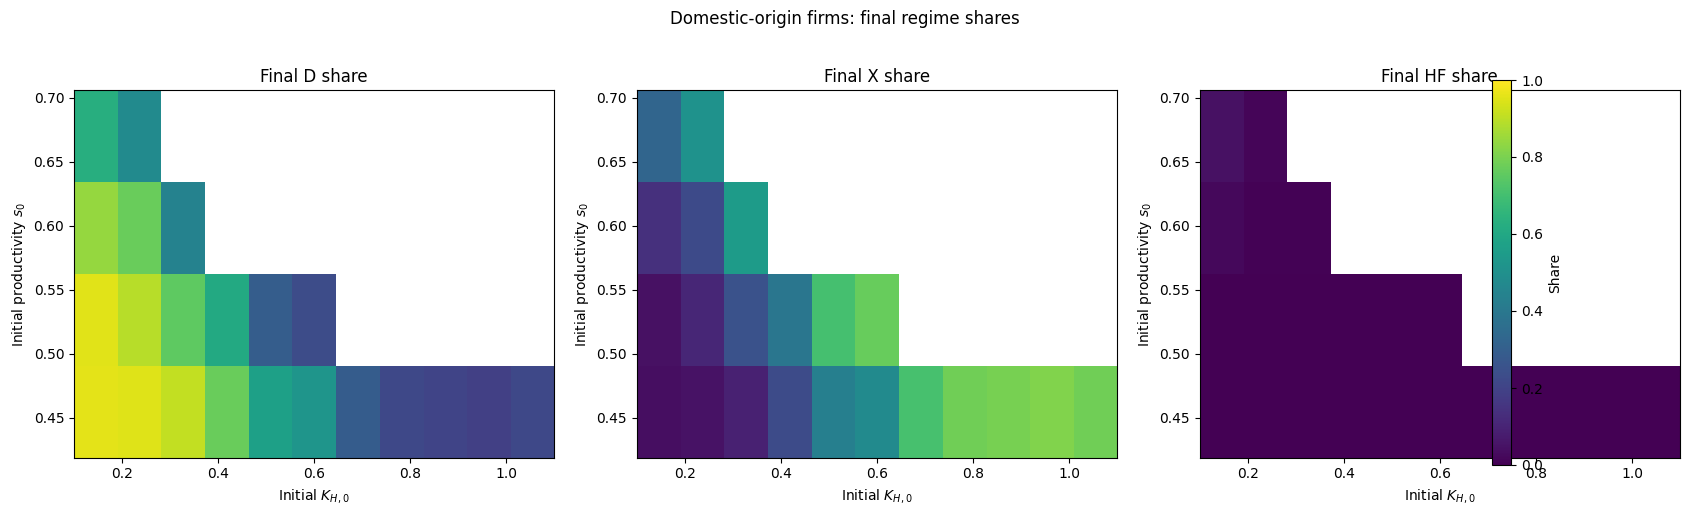

/var/folders/mz/9j0q2hw52gn0z79drwg1nbsw0000gn/T/ipykernel_63907/754161624.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


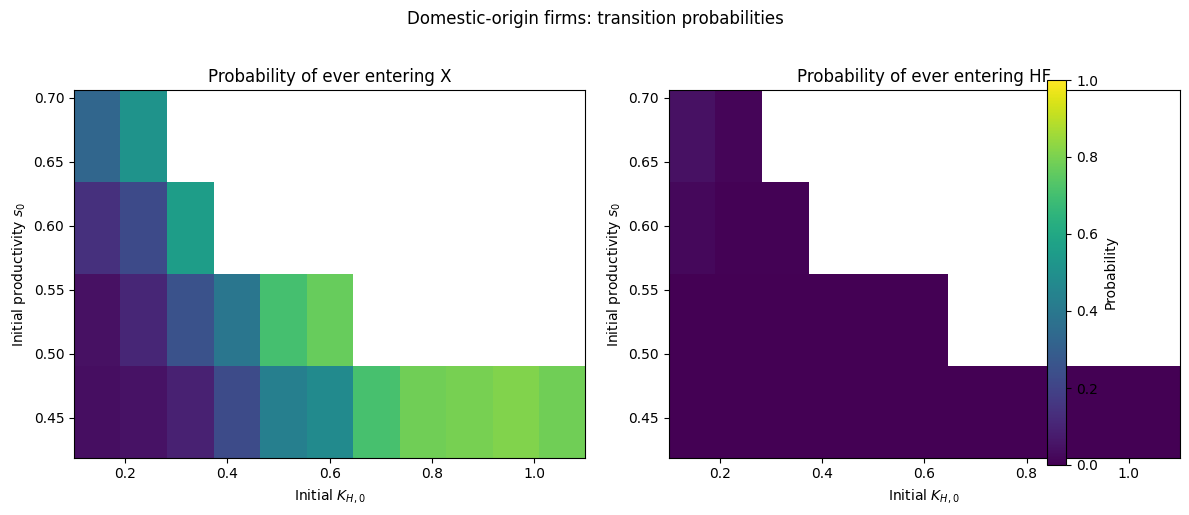

/var/folders/mz/9j0q2hw52gn0z79drwg1nbsw0000gn/T/ipykernel_63907/754161624.py:160: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


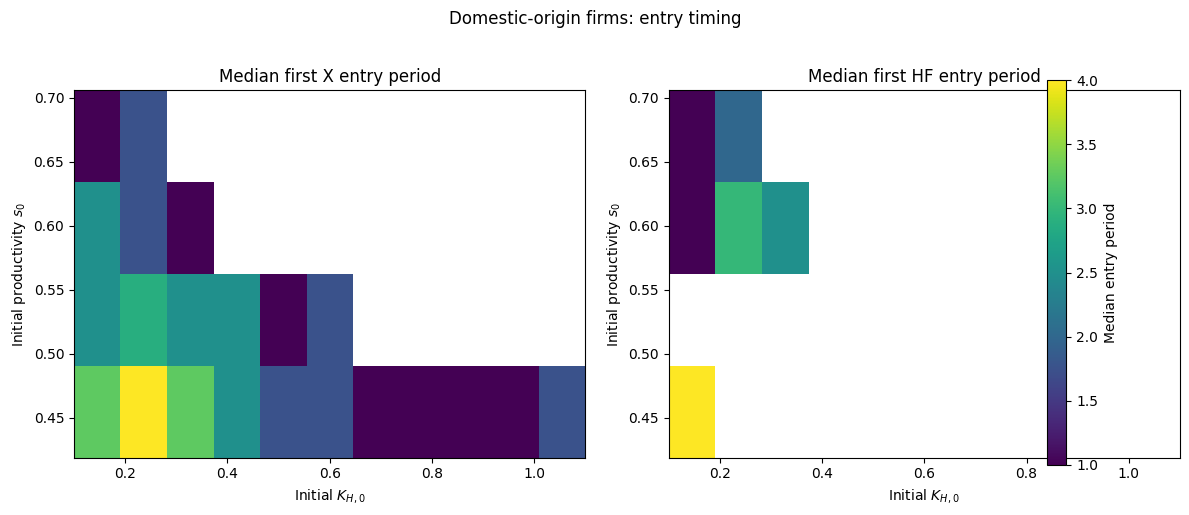

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def make_heatmap_matrix(df: pd.DataFrame, value_col: str):
    """
    Build a matrix with:
      rows    = s0
      columns = KH0
      entries = value_col
    """
    pivot = df.pivot(index="s0", columns="KH0", values=value_col)
    pivot = pivot.sort_index(axis=0).sort_index(axis=1)

    y_vals = pivot.index.to_numpy(dtype=float)
    x_vals = pivot.columns.to_numpy(dtype=float)
    Z = pivot.to_numpy(dtype=float)

    return x_vals, y_vals, Z

def plot_domestic_origin_heatmaps(agg_state_df_D: pd.DataFrame) -> None:
    """
    For firms starting from D, create:

    Figure 1: 1x3 final regime shares
      - final_d_share
      - final_x_share
      - final_hf_share

    Figure 2: 1x2 transition probabilities
      - ever_x_share
      - ever_hf_share

    Figure 3: 1x2 timing heatmaps
      - median_first_x_period
      - median_first_hf_period
    """

    # -----------------------------
    # Figure 1: Final regime shares
    # -----------------------------
    x_d, y_d, Z_final_d = make_heatmap_matrix(agg_state_df_D, "final_d_share")
    x_x, y_x, Z_final_x = make_heatmap_matrix(agg_state_df_D, "final_x_share")
    x_hf, y_hf, Z_final_hf = make_heatmap_matrix(agg_state_df_D, "final_hf_share")

    fig1, axes1 = plt.subplots(1, 3, figsize=(17, 5))

    im1 = axes1[0].imshow(
        Z_final_d,
        origin="lower",
        aspect="auto",
        extent=[x_d.min(), x_d.max(), y_d.min(), y_d.max()],
        vmin=0.0, vmax=1.0
    )
    axes1[0].set_xlabel(r"Initial $K_{H,0}$")
    axes1[0].set_ylabel(r"Initial productivity $s_0$")
    axes1[0].set_title("Final D share")

    im2 = axes1[1].imshow(
        Z_final_x,
        origin="lower",
        aspect="auto",
        extent=[x_x.min(), x_x.max(), y_x.min(), y_x.max()],
        vmin=0.0, vmax=1.0
    )
    axes1[1].set_xlabel(r"Initial $K_{H,0}$")
    axes1[1].set_ylabel(r"Initial productivity $s_0$")
    axes1[1].set_title("Final X share")

    im3 = axes1[2].imshow(
        Z_final_hf,
        origin="lower",
        aspect="auto",
        extent=[x_hf.min(), x_hf.max(), y_hf.min(), y_hf.max()],
        vmin=0.0, vmax=1.0
    )
    axes1[2].set_xlabel(r"Initial $K_{H,0}$")
    axes1[2].set_ylabel(r"Initial productivity $s_0$")
    axes1[2].set_title("Final HF share")

    cbar1 = fig1.colorbar(im3, ax=axes1, fraction=0.025, pad=0.02)
    cbar1.set_label("Share")

    fig1.suptitle("Domestic-origin firms: final regime shares", y=1.02)
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Figure 2: Transition probabilities
    # -----------------------------
    x_ex, y_ex, Z_ever_x = make_heatmap_matrix(agg_state_df_D, "ever_x_share")
    x_ehf, y_ehf, Z_ever_hf = make_heatmap_matrix(agg_state_df_D, "ever_hf_share")

    fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))

    im4 = axes2[0].imshow(
        Z_ever_x,
        origin="lower",
        aspect="auto",
        extent=[x_ex.min(), x_ex.max(), y_ex.min(), y_ex.max()],
        vmin=0.0, vmax=1.0
    )
    axes2[0].set_xlabel(r"Initial $K_{H,0}$")
    axes2[0].set_ylabel(r"Initial productivity $s_0$")
    axes2[0].set_title("Probability of ever entering X")

    im5 = axes2[1].imshow(
        Z_ever_hf,
        origin="lower",
        aspect="auto",
        extent=[x_ehf.min(), x_ehf.max(), y_ehf.min(), y_ehf.max()],
        vmin=0.0, vmax=1.0
    )
    axes2[1].set_xlabel(r"Initial $K_{H,0}$")
    axes2[1].set_ylabel(r"Initial productivity $s_0$")
    axes2[1].set_title("Probability of ever entering HF")

    cbar2 = fig2.colorbar(im5, ax=axes2, fraction=0.03, pad=0.02)
    cbar2.set_label("Probability")

    fig2.suptitle("Domestic-origin firms: transition probabilities", y=1.02)
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Figure 3: Timing heatmaps
    # -----------------------------
    x_tx, y_tx, Z_med_x = make_heatmap_matrix(agg_state_df_D, "median_first_x_period")
    x_thf, y_thf, Z_med_hf = make_heatmap_matrix(agg_state_df_D, "median_first_hf_period")

    Z_med_x_masked = np.ma.masked_invalid(Z_med_x)
    Z_med_hf_masked = np.ma.masked_invalid(Z_med_hf)

    fig3, axes3 = plt.subplots(1, 2, figsize=(12, 5))

    im6 = axes3[0].imshow(
        Z_med_x_masked,
        origin="lower",
        aspect="auto",
        extent=[x_tx.min(), x_tx.max(), y_tx.min(), y_tx.max()]
    )
    axes3[0].set_xlabel(r"Initial $K_{H,0}$")
    axes3[0].set_ylabel(r"Initial productivity $s_0$")
    axes3[0].set_title("Median first X entry period")

    im7 = axes3[1].imshow(
        Z_med_hf_masked,
        origin="lower",
        aspect="auto",
        extent=[x_thf.min(), x_thf.max(), y_thf.min(), y_thf.max()]
    )
    axes3[1].set_xlabel(r"Initial $K_{H,0}$")
    axes3[1].set_ylabel(r"Initial productivity $s_0$")
    axes3[1].set_title("Median first HF entry period")

    cbar3 = fig3.colorbar(im7, ax=axes3, fraction=0.03, pad=0.02)
    cbar3.set_label("Median entry period")

    fig3.suptitle("Domestic-origin firms: entry timing", y=1.02)
    plt.tight_layout()
    plt.show()


# Run:
plot_domestic_origin_heatmaps(agg_state_df_D)

/var/folders/mz/9j0q2hw52gn0z79drwg1nbsw0000gn/T/ipykernel_63907/337771287.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


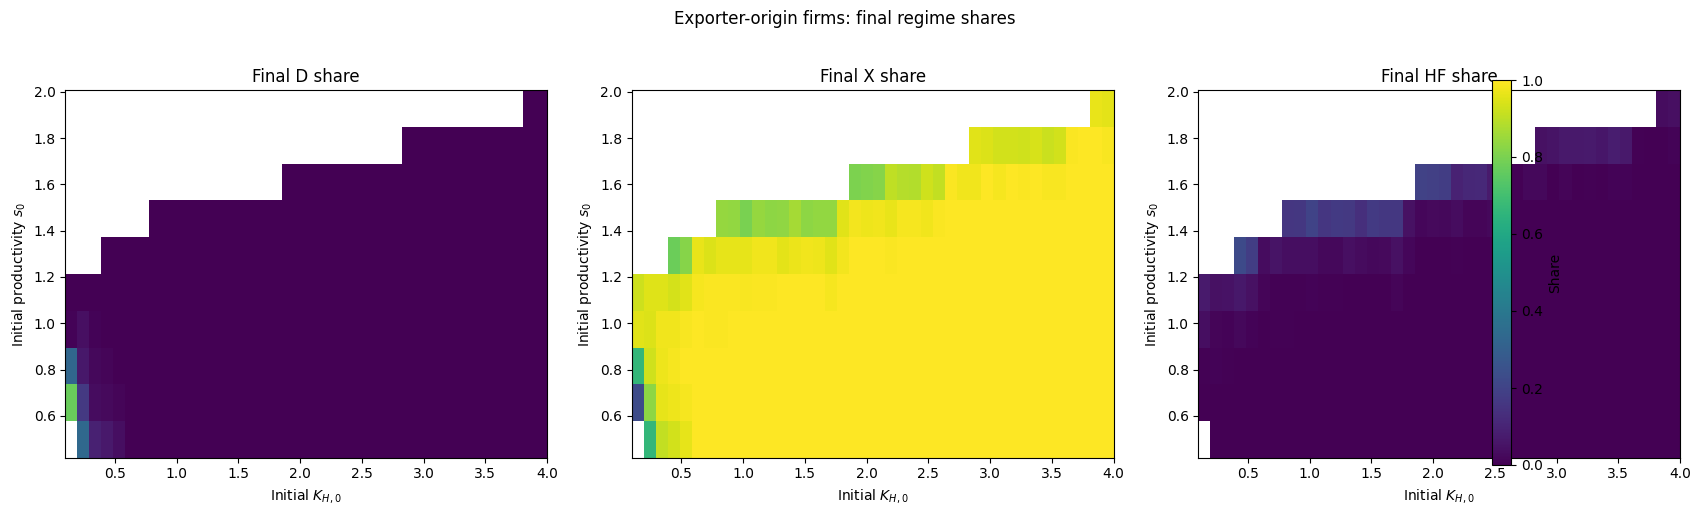

/var/folders/mz/9j0q2hw52gn0z79drwg1nbsw0000gn/T/ipykernel_63907/337771287.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


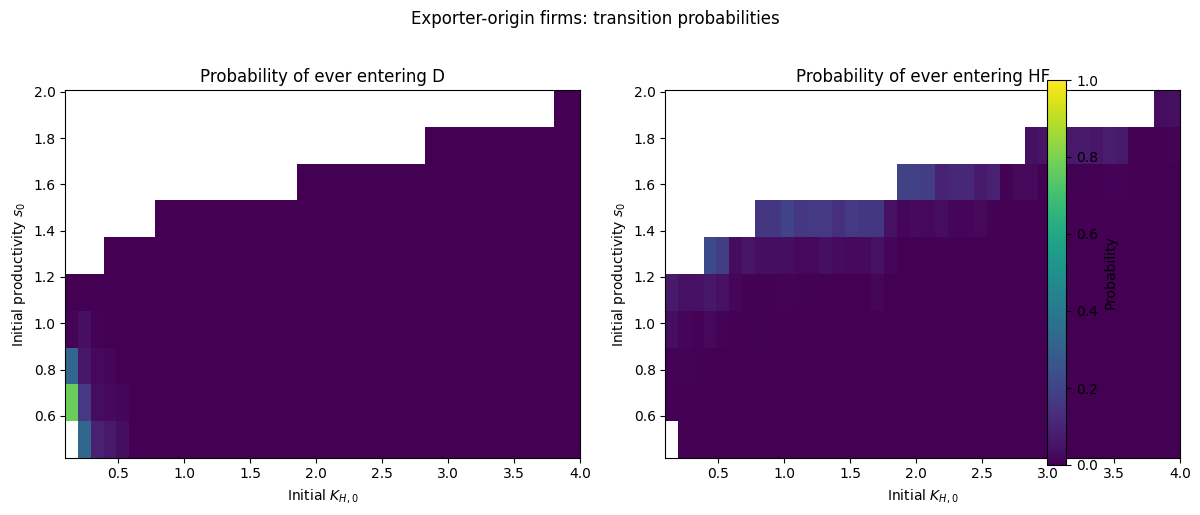

/var/folders/mz/9j0q2hw52gn0z79drwg1nbsw0000gn/T/ipykernel_63907/337771287.py:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


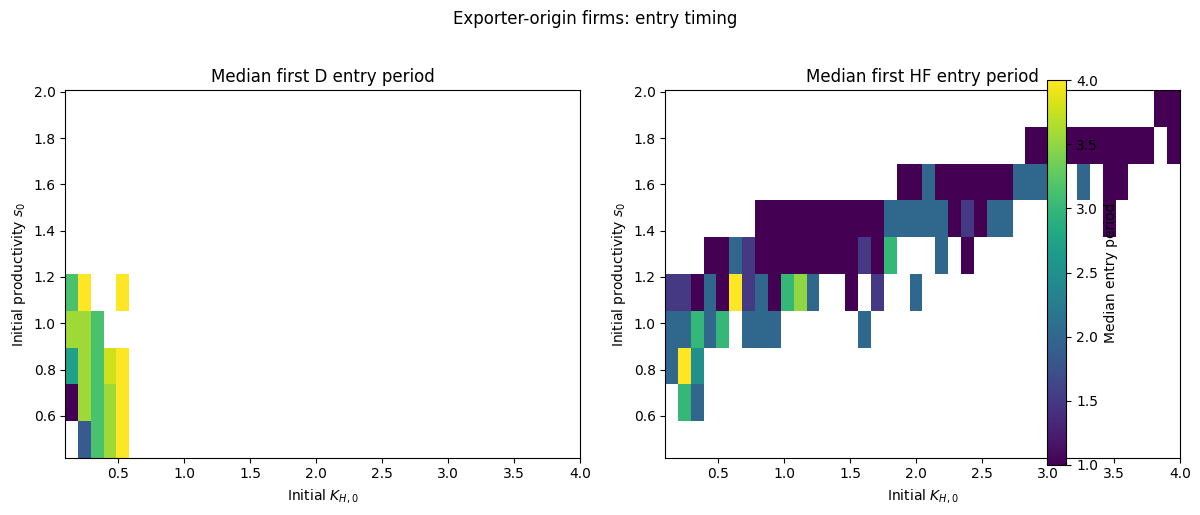

In [37]:
def plot_exporter_origin_heatmaps(agg_state_df_X: pd.DataFrame) -> None:
    """
    For firms starting from X, create:

    Figure 1: 1x3 final regime shares
      - final_d_share
      - final_x_share
      - final_hf_share

    Figure 2: 1x2 transition probabilities
      - ever_d_share
      - ever_hf_share

    Figure 3: 1x2 timing heatmaps
      - median_first_d_period
      - median_first_hf_period
    """

    # -----------------------------
    # Figure 1: Final regime shares
    # -----------------------------
    x_d, y_d, Z_final_d = make_heatmap_matrix(agg_state_df_X, "final_d_share")
    x_x, y_x, Z_final_x = make_heatmap_matrix(agg_state_df_X, "final_x_share")
    x_hf, y_hf, Z_final_hf = make_heatmap_matrix(agg_state_df_X, "final_hf_share")

    fig1, axes1 = plt.subplots(1, 3, figsize=(17, 5))

    im1 = axes1[0].imshow(
        Z_final_d,
        origin="lower",
        aspect="auto",
        extent=[x_d.min(), x_d.max(), y_d.min(), y_d.max()],
        vmin=0.0, vmax=1.0
    )
    axes1[0].set_xlabel(r"Initial $K_{H,0}$")
    axes1[0].set_ylabel(r"Initial productivity $s_0$")
    axes1[0].set_title("Final D share")

    im2 = axes1[1].imshow(
        Z_final_x,
        origin="lower",
        aspect="auto",
        extent=[x_x.min(), x_x.max(), y_x.min(), y_x.max()],
        vmin=0.0, vmax=1.0
    )
    axes1[1].set_xlabel(r"Initial $K_{H,0}$")
    axes1[1].set_ylabel(r"Initial productivity $s_0$")
    axes1[1].set_title("Final X share")

    im3 = axes1[2].imshow(
        Z_final_hf,
        origin="lower",
        aspect="auto",
        extent=[x_hf.min(), x_hf.max(), y_hf.min(), y_hf.max()],
        vmin=0.0, vmax=1.0
    )
    axes1[2].set_xlabel(r"Initial $K_{H,0}$")
    axes1[2].set_ylabel(r"Initial productivity $s_0$")
    axes1[2].set_title("Final HF share")

    cbar1 = fig1.colorbar(im3, ax=axes1, fraction=0.025, pad=0.02)
    cbar1.set_label("Share")

    fig1.suptitle("Exporter-origin firms: final regime shares", y=1.02)
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Figure 2: Transition probabilities
    # -----------------------------
    x_ed, y_ed, Z_ever_d = make_heatmap_matrix(agg_state_df_X, "ever_d_share")
    x_ehf, y_ehf, Z_ever_hf = make_heatmap_matrix(agg_state_df_X, "ever_hf_share")

    fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))

    im4 = axes2[0].imshow(
        Z_ever_d,
        origin="lower",
        aspect="auto",
        extent=[x_ed.min(), x_ed.max(), y_ed.min(), y_ed.max()],
        vmin=0.0, vmax=1.0
    )
    axes2[0].set_xlabel(r"Initial $K_{H,0}$")
    axes2[0].set_ylabel(r"Initial productivity $s_0$")
    axes2[0].set_title("Probability of ever entering D")

    im5 = axes2[1].imshow(
        Z_ever_hf,
        origin="lower",
        aspect="auto",
        extent=[x_ehf.min(), x_ehf.max(), y_ehf.min(), y_ehf.max()],
        vmin=0.0, vmax=1.0
    )
    axes2[1].set_xlabel(r"Initial $K_{H,0}$")
    axes2[1].set_ylabel(r"Initial productivity $s_0$")
    axes2[1].set_title("Probability of ever entering HF")

    cbar2 = fig2.colorbar(im5, ax=axes2, fraction=0.03, pad=0.02)
    cbar2.set_label("Probability")

    fig2.suptitle("Exporter-origin firms: transition probabilities", y=1.02)
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Figure 3: Timing heatmaps
    # -----------------------------
    x_td, y_td, Z_med_d = make_heatmap_matrix(agg_state_df_X, "median_first_d_period")
    x_thf, y_thf, Z_med_hf = make_heatmap_matrix(agg_state_df_X, "median_first_hf_period")

    Z_med_d_masked = np.ma.masked_invalid(Z_med_d)
    Z_med_hf_masked = np.ma.masked_invalid(Z_med_hf)

    fig3, axes3 = plt.subplots(1, 2, figsize=(12, 5))

    im6 = axes3[0].imshow(
        Z_med_d_masked,
        origin="lower",
        aspect="auto",
        extent=[x_td.min(), x_td.max(), y_td.min(), y_td.max()]
    )
    axes3[0].set_xlabel(r"Initial $K_{H,0}$")
    axes3[0].set_ylabel(r"Initial productivity $s_0$")
    axes3[0].set_title("Median first D entry period")

    im7 = axes3[1].imshow(
        Z_med_hf_masked,
        origin="lower",
        aspect="auto",
        extent=[x_thf.min(), x_thf.max(), y_thf.min(), y_thf.max()]
    )
    axes3[1].set_xlabel(r"Initial $K_{H,0}$")
    axes3[1].set_ylabel(r"Initial productivity $s_0$")
    axes3[1].set_title("Median first HF entry period")

    cbar3 = fig3.colorbar(im7, ax=axes3, fraction=0.03, pad=0.02)
    cbar3.set_label("Median entry period")

    fig3.suptitle("Exporter-origin firms: entry timing", y=1.02)
    plt.tight_layout()
    plt.show()

plot_exporter_origin_heatmaps(agg_state_df_X)

###  Pick 3 inital states
1. Low probability of entering HF
2. 50% probability of enter HF
3. High probability of entering HF 

In [139]:
import numpy as np
import pandas as pd

def pick_representative_states(
    agg_state_df: pd.DataFrame,
    targets=(0.10, 0.50, 1.00),
    labels=("low", "middle", "high"),
) -> pd.DataFrame:
    """
    Pick three representative initial states:
      - one close to low HF-entry probability
      - one close to 50%
      - one close to high HF-entry probability

    Uses hf_share_ever from agg_state_df.
    """
    if len(targets) != len(labels):
        raise ValueError("targets and labels must have the same length.")

    df = agg_state_df.copy()
    chosen_rows = []
    used_state_ids = set()

    for target, label in zip(targets, labels):
        cand = df.loc[~df["state_id"].isin(used_state_ids)].copy()
        cand["distance_to_target"] = (cand["hf_share_ever"] - target).abs()

        # tie-break toward cleaner states
        cand = cand.sort_values(
            ["distance_to_target", "s0", "KH0"],
            ascending=[True, True, True]
        )

        row = cand.iloc[0].copy()
        row["target_prob"] = target
        row["label"] = label

        chosen_rows.append(row)
        used_state_ids.add(int(row["state_id"]))

    out = pd.DataFrame(chosen_rows).reset_index(drop=True)
    return out[
        [
            "label",
            "target_prob",
            "state_id",
            "s0",
            "KH0",
            "KF0",
            "hf_share_ever",
            "mean_entry_period",
            "stay_x_share",
            "initial_profit_X",
        ]
    ]


selected_states = pick_representative_states(agg_state_df)
print(selected_states)

    label  target_prob  state_id   s0  KH0  KF0  hf_share_ever  \
0     low          0.1     277.0  1.0  1.4  0.0       0.100000   
1  middle          0.5     268.0  1.0  0.5  0.0       0.453333   
2    high          1.0     264.0  1.0  0.1  0.0       1.000000   

   mean_entry_period  stay_x_share  initial_profit_X  
0           3.500000      0.900000          0.332879  
1           2.566176      0.546667          0.170501  
2           1.000000      0.000000          0.044576  


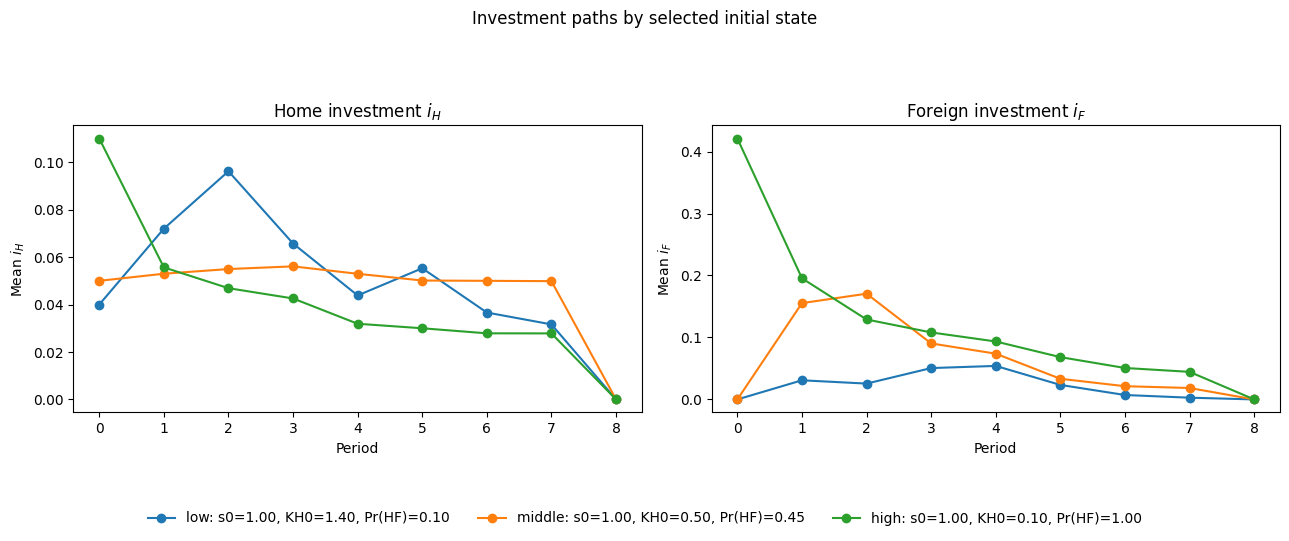

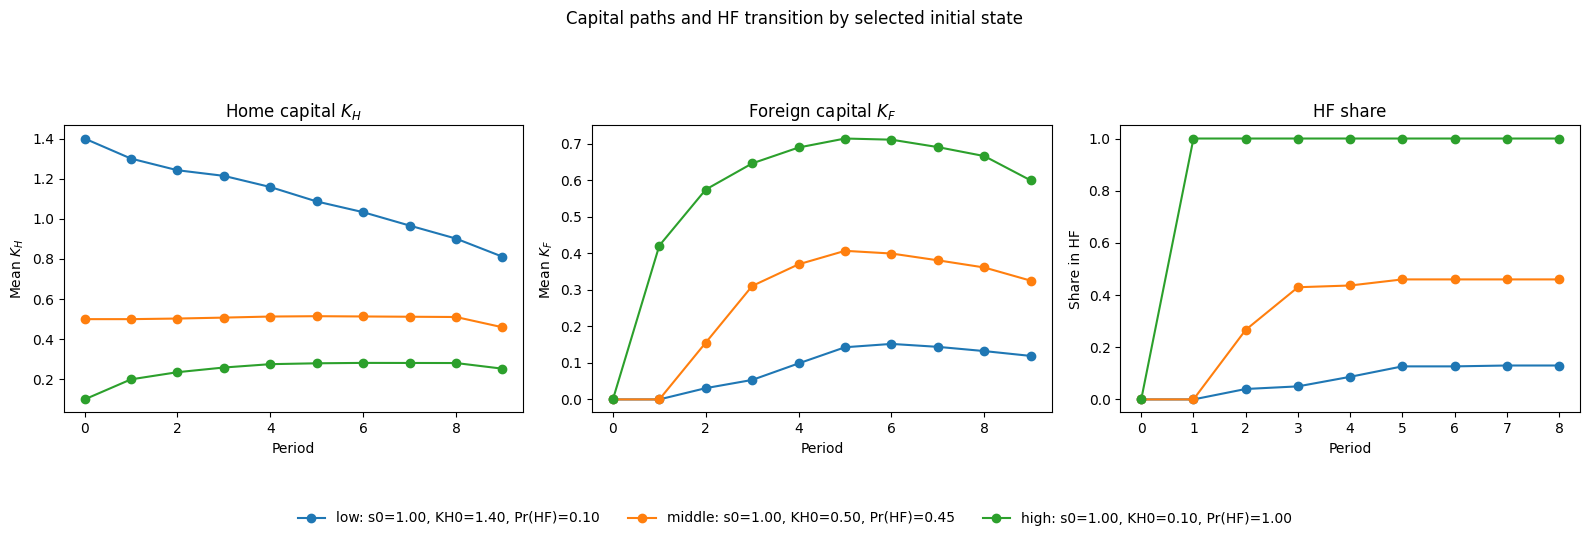

In [140]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_selected_states(
    model_bundle: Dict[str, object],
    selected_states: pd.DataFrame,
    N: int = 300,
    stochastic: bool = True,
    initial_prev_mode: str = "X",
    seed: int = 123,
) -> dict:
    """
    Simulate N firms from each selected initial state.
    Returns a dict keyed by label.
    """
    out = {}

    for idx, row in selected_states.iterrows():
        label = str(row["label"])

        paths = simulate_many_paths(
            model_bundle=model_bundle,
            KH0=float(row["KH0"]),
            KF0=float(row["KF0"]),
            s0_idx=int(nearest_index(model_bundle["s_grid"], float(row["s0"]))),
            n_firms=N,
            initial_prev_mode=initial_prev_mode,
            stochastic=stochastic,
            seed=seed + idx,
        )

        out[label] = {
            "state_info": row.to_dict(),
            "paths": paths,
        }

    return out


def plot_selected_state_figures(sim_selected: dict) -> None:
    """
    Create:
      1. one 1x2 figure for mean investment paths (i_H, i_F)
      2. one 1x3 figure for mean capital paths (K_H, K_F) and HF share
    """

    # -----------------------------
    # Figure 1: Investment paths (1x2)
    # -----------------------------
    fig1, axes1 = plt.subplots(1, 2, figsize=(13, 4.8))

    for label, obj in sim_selected.items():
        paths = obj["paths"]
        row = obj["state_info"]

        arr_iH = np.array([p["iH_path"] for p in paths], dtype=float)
        arr_iF = np.array([p["iF_path"] for p in paths], dtype=float)

        mean_iH = arr_iH.mean(axis=0)
        mean_iF = arr_iF.mean(axis=0)

        legend_label = (
            f"{label}: s0={row['s0']:.2f}, KH0={row['KH0']:.2f}, "
            f"Pr(HF)={row['hf_share_ever']:.2f}"
        )

        axes1[0].plot(range(len(mean_iH)), mean_iH, marker="o", label=legend_label)
        axes1[1].plot(range(len(mean_iF)), mean_iF, marker="o", label=legend_label)

    axes1[0].set_xlabel("Period")
    axes1[0].set_ylabel(r"Mean $i_H$")
    axes1[0].set_title(r"Home investment $i_H$")

    axes1[1].set_xlabel("Period")
    axes1[1].set_ylabel(r"Mean $i_F$")
    axes1[1].set_title(r"Foreign investment $i_F$")

    handles1, labels1 = axes1[0].get_legend_handles_labels()
    fig1.legend(handles1, labels1, loc="lower center", bbox_to_anchor=(0.5, -0.06), ncol=min(3, len(labels1)), frameon=False)
    fig1.suptitle("Investment paths by selected initial state", y=1.04)
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.show()

    # -----------------------------
    # Figure 2: Capital + HF share (1x3)
    # -----------------------------
    fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4.8))

    for label, obj in sim_selected.items():
        paths = obj["paths"]
        row = obj["state_info"]

        arr_KH = np.array([p["KH_path"] for p in paths], dtype=float)
        arr_KF = np.array([p["KF_path"] for p in paths], dtype=float)
        hf_share_t = np.array([
            [1.0 if m == "HF" else 0.0 for m in p["mode_path"]]
            for p in paths
        ]).mean(axis=0)

        mean_KH = arr_KH.mean(axis=0)
        mean_KF = arr_KF.mean(axis=0)

        legend_label = (
            f"{label}: s0={row['s0']:.2f}, KH0={row['KH0']:.2f}, "
            f"Pr(HF)={row['hf_share_ever']:.2f}"
        )

        axes2[0].plot(range(len(mean_KH)), mean_KH, marker="o", label=legend_label)
        axes2[1].plot(range(len(mean_KF)), mean_KF, marker="o", label=legend_label)
        axes2[2].plot(range(len(hf_share_t)), hf_share_t, marker="o", label=legend_label)

    axes2[0].set_xlabel("Period")
    axes2[0].set_ylabel(r"Mean $K_H$")
    axes2[0].set_title(r"Home capital $K_H$")

    axes2[1].set_xlabel("Period")
    axes2[1].set_ylabel(r"Mean $K_F$")
    axes2[1].set_title(r"Foreign capital $K_F$")

    axes2[2].set_xlabel("Period")
    axes2[2].set_ylabel("Share in HF")
    axes2[2].set_title("HF share")

    handles2, labels2 = axes2[0].get_legend_handles_labels()
    fig2.legend(handles2, labels2, loc="lower center", bbox_to_anchor=(0.5, -0.06), ncol=min(3, len(labels2)), frameon=False)
    fig2.suptitle("Capital paths and HF transition by selected initial state", y=1.04)
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.show()


# -----------------------------
# Run
# -----------------------------
sim_selected = simulate_selected_states(
    model_bundle=model_stoch,
    selected_states=selected_states,
    N=300,
    stochastic=True,
    initial_prev_mode="X",
    seed=123,
)

plot_selected_state_figures(sim_selected)

# Focus on Middle intial state
seperate by if the firm ever enter HF or not 

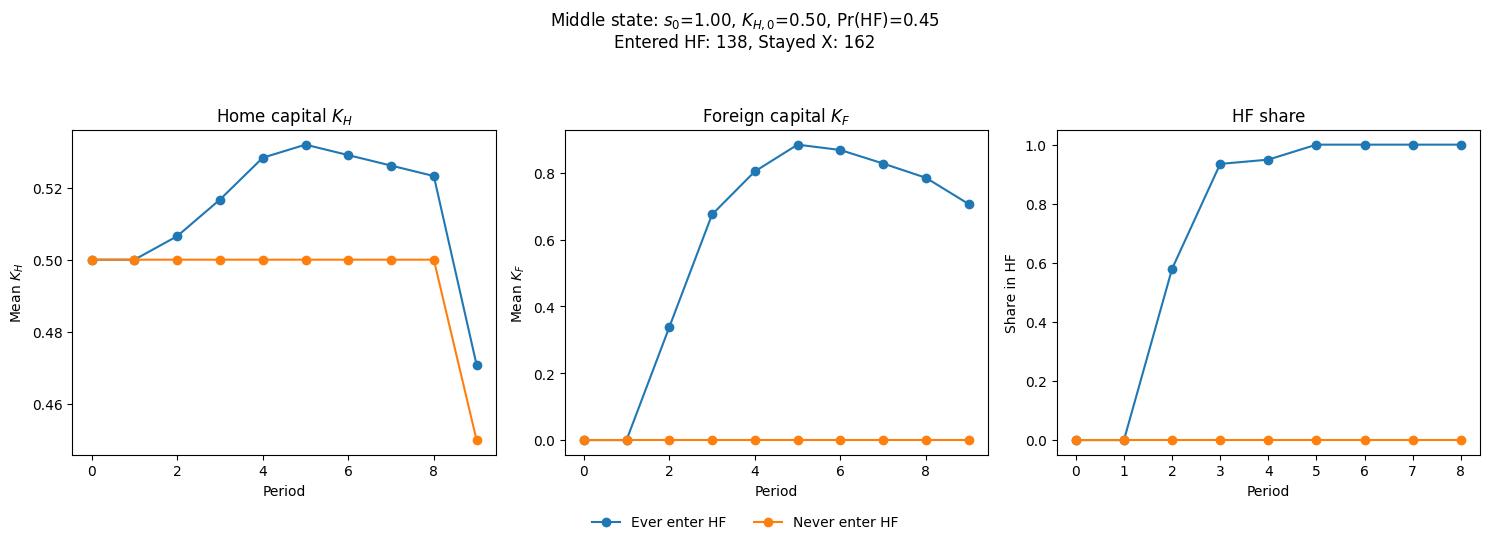

In [141]:
import numpy as np
import matplotlib.pyplot as plt

def plot_middle_state_divergence_1x3(
    sim_selected: dict,
    middle_label: str = "middle",
) -> None:
    """
    For the selected 'middle' state, split simulated firms into:
      - ever enter HF
      - never enter HF

    Then plot a 1x3 figure with average paths for:
      1. K_H
      2. K_F
      3. share in HF over time
    """
    if middle_label not in sim_selected:
        raise ValueError(f"Label '{middle_label}' not found in sim_selected.")

    paths = sim_selected[middle_label]["paths"]
    state_info = sim_selected[middle_label]["state_info"]

    entered_hf = [p for p in paths if any(m == "HF" for m in p["mode_path"])]
    stayed_x = [p for p in paths if all(m == "X" for m in p["mode_path"])]

    n_entered = len(entered_hf)
    n_stayed = len(stayed_x)

    if n_entered == 0:
        raise ValueError("No firms in the middle state enter HF.")
    if n_stayed == 0:
        raise ValueError("All firms in the middle state enter HF; no comparison group.")

    def mean_path(path_list, key):
        return np.array([p[key] for p in path_list], dtype=float).mean(axis=0)

    def hf_share_path(path_list):
        return np.array([
            [1.0 if m == "HF" else 0.0 for m in p["mode_path"]]
            for p in path_list
        ]).mean(axis=0)

    mean_KH_enter = mean_path(entered_hf, "KH_path")
    mean_KH_stay = mean_path(stayed_x, "KH_path")

    mean_KF_enter = mean_path(entered_hf, "KF_path")
    mean_KF_stay = mean_path(stayed_x, "KF_path")

    hf_share_enter = hf_share_path(entered_hf)
    hf_share_stay = hf_share_path(stayed_x)

    t_cap = np.arange(len(mean_KH_enter))
    t_mode = np.arange(len(hf_share_enter))

    title_text = (
        f"Middle state: $s_0$={state_info['s0']:.2f}, "
        f"$K_{{H,0}}$={state_info['KH0']:.2f}, "
        f"Pr(HF)={state_info['hf_share_ever']:.2f}\n"
        f"Entered HF: {n_entered}, Stayed X: {n_stayed}"
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

    # Panel 1: K_H
    axes[0].plot(t_cap, mean_KH_enter, marker="o", label="Ever enter HF")
    axes[0].plot(t_cap, mean_KH_stay, marker="o", label="Never enter HF")
    axes[0].set_xlabel("Period")
    axes[0].set_ylabel(r"Mean $K_H$")
    axes[0].set_title(r"Home capital $K_H$")

    # Panel 2: K_F
    axes[1].plot(t_cap, mean_KF_enter, marker="o", label="Ever enter HF")
    axes[1].plot(t_cap, mean_KF_stay, marker="o", label="Never enter HF")
    axes[1].set_xlabel("Period")
    axes[1].set_ylabel(r"Mean $K_F$")
    axes[1].set_title(r"Foreign capital $K_F$")

    # Panel 3: Share in HF
    axes[2].plot(t_mode, hf_share_enter, marker="o", label="Ever enter HF")
    axes[2].plot(t_mode, hf_share_stay, marker="o", label="Never enter HF")
    axes[2].set_xlabel("Period")
    axes[2].set_ylabel("Share in HF")
    axes[2].set_title("HF share")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.06), ncol=min(3, len(labels)), frameon=False)
    fig.suptitle(title_text, y=1.05)
    plt.tight_layout()
    plt.show()


# Run:
plot_middle_state_divergence_1x3(sim_selected, middle_label="middle")

#### Condition on when firm enters HF

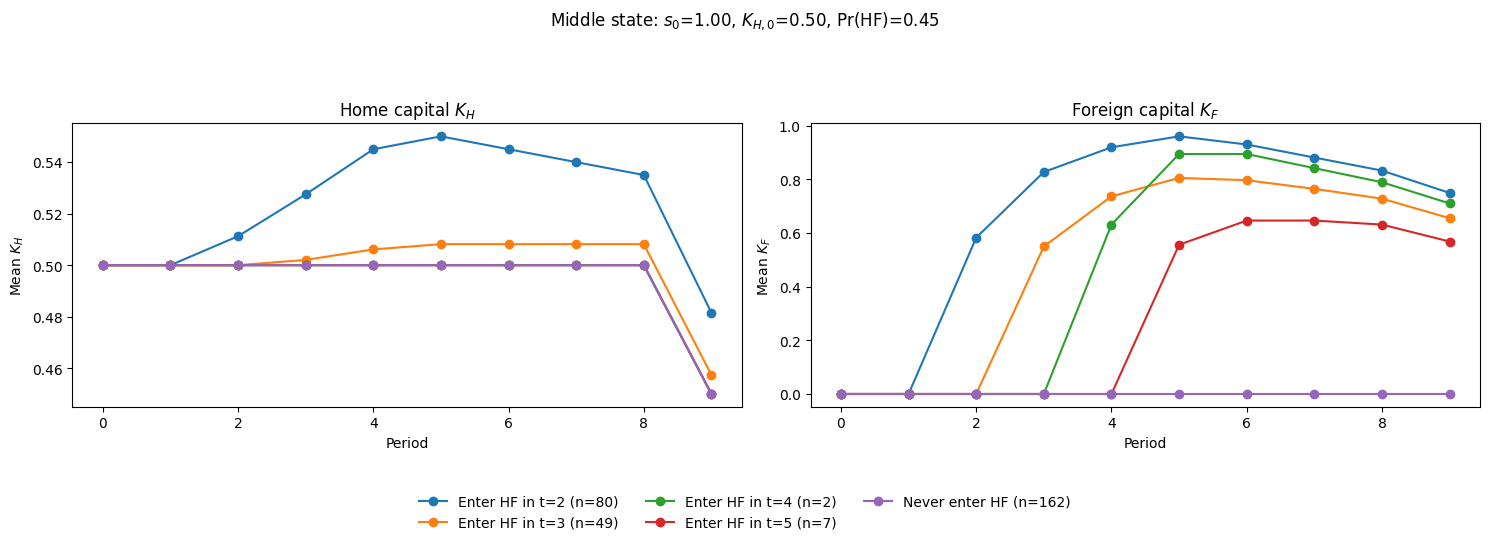

In [142]:
import numpy as np
import matplotlib.pyplot as plt

def plot_middle_state_by_entry_period_1x3(
    sim_selected: dict,
    middle_label: str = "middle",
    min_group_size: int = 1,
) -> None:
    """
    For the selected 'middle' state, group firms by the first period in which HF is entered.
    Adds one extra group for firms that never enter HF.

    Then plot a 1x3 figure with average paths for:
      1. K_H
      2. K_F
      3. share in HF over time

    Parameters
    ----------
    sim_selected : dict
        Output from simulate_selected_states(...)
    middle_label : str
        Key for the middle state in sim_selected
    min_group_size : int
        Only plot groups with at least this many firms
    """
    if middle_label not in sim_selected:
        raise ValueError(f"Label '{middle_label}' not found in sim_selected.")

    paths = sim_selected[middle_label]["paths"]
    state_info = sim_selected[middle_label]["state_info"]

    def first_hf_entry_period(mode_path):
        for t, m in enumerate(mode_path):
            if m == "HF":
                return t
        return None

    # ---------------------------------------
    # Build groups: t=0,1,2,... and "never"
    # ---------------------------------------
    groups = {}
    for p in paths:
        entry_t = first_hf_entry_period(p["mode_path"])
        key = "never" if entry_t is None else int(entry_t)
        groups.setdefault(key, []).append(p)

    # Keep only sufficiently large groups
    groups = {k: v for k, v in groups.items() if len(v) >= min_group_size}
    if len(groups) == 0:
        raise ValueError("No groups satisfy min_group_size.")

    # Sort groups: entry periods first, then never
    ordered_keys = sorted([k for k in groups.keys() if k != "never"])
    if "never" in groups:
        ordered_keys.append("never")

    def mean_path(path_list, key):
        return np.array([p[key] for p in path_list], dtype=float).mean(axis=0)

    def hf_share_path(path_list):
        return np.array([
            [1.0 if m == "HF" else 0.0 for m in p["mode_path"]]
            for p in path_list
        ]).mean(axis=0)

    # Use first group to get lengths
    first_group = groups[ordered_keys[0]]
    t_cap = np.arange(len(first_group[0]["KH_path"]))
    t_mode = np.arange(len(first_group[0]["mode_path"]))

    title_text = (
        f"Middle state: $s_0$={state_info['s0']:.2f}, "
        f"$K_{{H,0}}$={state_info['KH0']:.2f}, "
        f"Pr(HF)={state_info['hf_share_ever']:.2f}"
    )

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

    for key in ordered_keys:
        grp = groups[key]
        n_grp = len(grp)

        mean_KH = mean_path(grp, "KH_path")
        mean_KF = mean_path(grp, "KF_path")

        if key == "never":
            label = f"Never enter HF (n={n_grp})"
        else:
            label = f"Enter HF in t={key} (n={n_grp})"

        axes[0].plot(t_cap, mean_KH, marker="o", label=label)
        axes[1].plot(t_cap, mean_KF, marker="o", label=label)

    # Panel 1
    axes[0].set_xlabel("Period")
    axes[0].set_ylabel(r"Mean $K_H$")
    axes[0].set_title(r"Home capital $K_H$")

    # Panel 2
    axes[1].set_xlabel("Period")
    axes[1].set_ylabel(r"Mean $K_F$")
    axes[1].set_title(r"Foreign capital $K_F$")


    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.08),
        ncol=min(3, len(labels)),
        frameon=False
    )
    fig.suptitle(title_text, y=1.03)
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.show()


# Run:
plot_middle_state_by_entry_period_1x3(
    sim_selected,
    middle_label="middle",
    min_group_size=1,   # raise to 5 or 10 if you want to suppress tiny groups
)

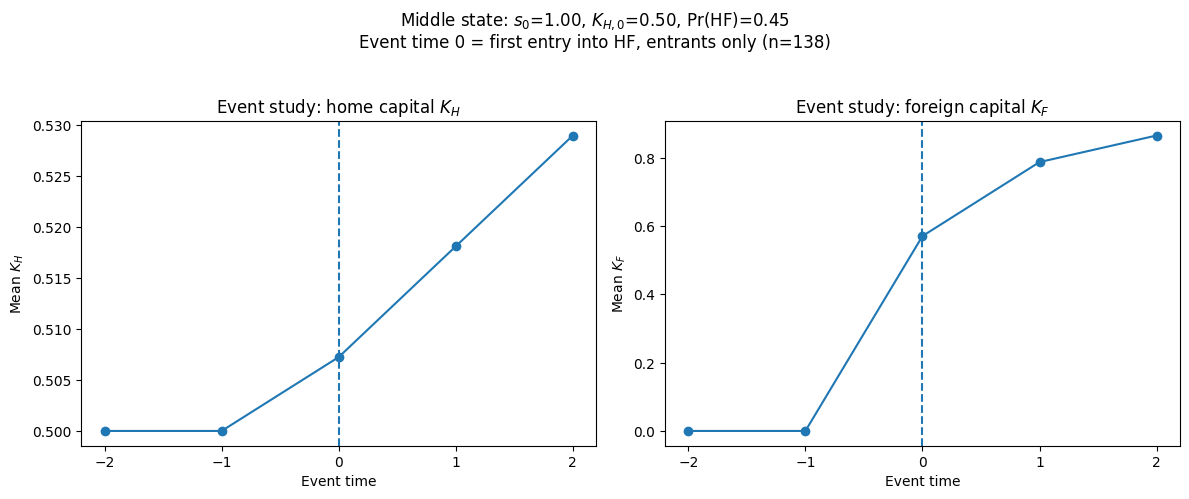

Number of observations contributing at each event time:
  t = -2: 138
  t = -1: 138
  t = +0: 138
  t = +1: 138
  t = +2: 138


In [143]:
import numpy as np
import matplotlib.pyplot as plt

def plot_middle_state_event_study(
    sim_selected: dict,
    middle_label: str = "middle",
    window_pre: int = 2,
    window_post: int = 2,
) -> None:
    """
    Event-study for the selected middle state.
    Uses only firms that ever enter HF and aligns paths by the first HF entry period.

    Plots mean K_H and mean K_F from event time -window_pre to +window_post,
    where event time 0 is first entry into HF.
    """
    if middle_label not in sim_selected:
        raise ValueError(f"Label '{middle_label}' not found in sim_selected.")

    paths = sim_selected[middle_label]["paths"]
    state_info = sim_selected[middle_label]["state_info"]

    def first_hf_entry_period(mode_path):
        for t, m in enumerate(mode_path):
            if m == "HF":
                return t
        return None

    event_times = np.arange(-window_pre, window_post + 1)

    kh_rows = []
    kf_rows = []

    for p in paths:
        entry_t = first_hf_entry_period(p["mode_path"])
        if entry_t is None:
            continue

        KH_path = p["KH_path"]   # length = n_periods + 1
        KF_path = p["KF_path"]

        kh_row = []
        kf_row = []

        for tau in event_times:
            t = entry_t + tau

            # Capital is indexed by period state, so valid indices are 0,...,n_periods
            if 0 <= t < len(KH_path):
                kh_row.append(KH_path[t])
                kf_row.append(KF_path[t])
            else:
                kh_row.append(np.nan)
                kf_row.append(np.nan)

        kh_rows.append(kh_row)
        kf_rows.append(kf_row)

    if len(kh_rows) == 0:
        raise ValueError("No firms in the selected state enter HF, so no event study can be computed.")

    KH_event = np.array(kh_rows, dtype=float)
    KF_event = np.array(kf_rows, dtype=float)

    mean_KH = np.nanmean(KH_event, axis=0)
    mean_KF = np.nanmean(KF_event, axis=0)

    n_by_tau = np.sum(~np.isnan(KH_event), axis=0)

    title_text = (
        f"Middle state: $s_0$={state_info['s0']:.2f}, "
        f"$K_{{H,0}}$={state_info['KH0']:.2f}, "
        f"Pr(HF)={state_info['hf_share_ever']:.2f}\n"
        f"Event time 0 = first entry into HF, entrants only (n={KH_event.shape[0]})"
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

    # Panel 1: K_H
    axes[0].plot(event_times, mean_KH, marker="o")
    axes[0].axvline(0, linestyle="--")
    axes[0].set_xlabel("Event time")
    axes[0].set_ylabel(r"Mean $K_H$")
    axes[0].set_title(r"Event study: home capital $K_H$")
    axes[0].set_xticks(event_times)

    # Panel 2: K_F
    axes[1].plot(event_times, mean_KF, marker="o")
    axes[1].axvline(0, linestyle="--")
    axes[1].set_xlabel("Event time")
    axes[1].set_ylabel(r"Mean $K_F$")
    axes[1].set_title(r"Event study: foreign capital $K_F$")
    axes[1].set_xticks(event_times)

    fig.suptitle(title_text, y=1.03)
    plt.tight_layout()
    plt.show()

    # Optional: print support counts for each event time
    print("Number of observations contributing at each event time:")
    for tau, n in zip(event_times, n_by_tau):
        print(f"  t = {tau:+d}: {int(n)}")


# Run:
plot_middle_state_event_study(
    sim_selected,
    middle_label="middle",
    window_pre=2,
    window_post=2,
)

## Distrbutions in final period
1. Create a distribution of the productivity by state 
2. Create a distribution of the caqpital stock by state

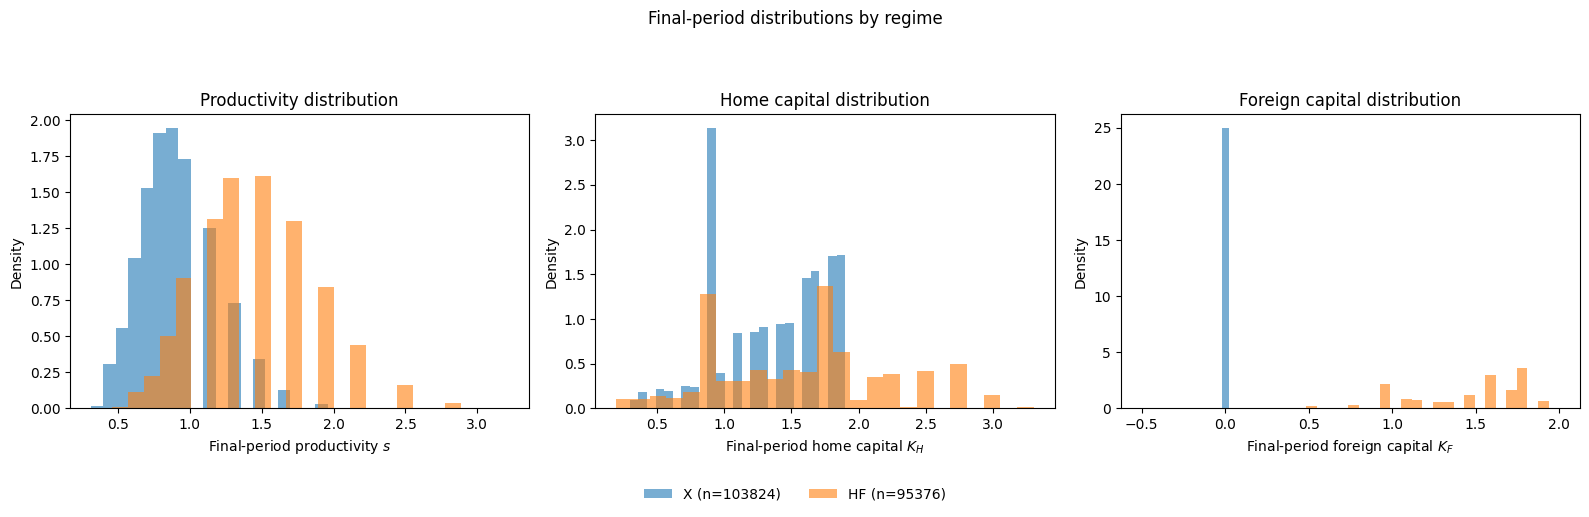

In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def build_final_period_distribution_df(sim_grid: list[dict]) -> pd.DataFrame:
    """
    Build a DataFrame with the final operational-period state from the simulated paths.

    Final operational period means:
      - regime: mode_path[-1]
      - productivity: s_path[-1]
      - capital stocks used in that period: KH_path[-2], KF_path[-2]

    Returns one row per simulated firm-path.
    """
    rows = []

    for state in sim_grid:
        for firm_id, path in enumerate(state["paths"]):
            final_mode = path["mode_path"][-1]
            final_s = float(path["s_path"][-1])

            # Final operating-period capital stocks
            final_KH = float(path["KH_path"][-2])
            final_KF = float(path["KF_path"][-2])

            rows.append({
                "state_id": state["state_id"],
                "firm_id": firm_id,
                "s0": state["s0"],
                "KH0": state["KH0"],
                "KF0": state["KF0"],
                "final_mode": final_mode,
                "final_s": final_s,
                "final_KH": final_KH,
                "final_KF": final_KF,
            })

    return pd.DataFrame(rows)


def plot_final_period_distributions(final_df: pd.DataFrame, bins: int = 25) -> None:
    """
    Plot 1x3 histograms of final-period distributions by final regime:
      1. productivity s
      2. home capital K_H
      3. foreign capital K_F
    """
    df_X = final_df.loc[final_df["final_mode"] == "X"].copy()
    df_HF = final_df.loc[final_df["final_mode"] == "HF"].copy()

    if len(df_X) == 0:
        raise ValueError("No firms end in regime X.")
    if len(df_HF) == 0:
        raise ValueError("No firms end in regime HF.")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

    # Panel 1: productivity
    axes[0].hist(df_X["final_s"], bins=bins, density=True, alpha=0.6, label=f"X (n={len(df_X)})")
    axes[0].hist(df_HF["final_s"], bins=bins, density=True, alpha=0.6, label=f"HF (n={len(df_HF)})")
    axes[0].set_xlabel(r"Final-period productivity $s$")
    axes[0].set_ylabel("Density")
    axes[0].set_title("Productivity distribution")

    # Panel 2: home capital
    axes[1].hist(df_X["final_KH"], bins=bins, density=True, alpha=0.6, label=f"X (n={len(df_X)})")
    axes[1].hist(df_HF["final_KH"], bins=bins, density=True, alpha=0.6, label=f"HF (n={len(df_HF)})")
    axes[1].set_xlabel(r"Final-period home capital $K_H$")
    axes[1].set_ylabel("Density")
    axes[1].set_title(r"Home capital distribution")

    # Panel 3: foreign capital
    axes[2].hist(df_X["final_KF"], bins=bins, density=True, alpha=0.6, label=f"X (n={len(df_X)})")
    axes[2].hist(df_HF["final_KF"], bins=bins, density=True, alpha=0.6, label=f"HF (n={len(df_HF)})")
    axes[2].set_xlabel(r"Final-period foreign capital $K_F$")
    axes[2].set_ylabel("Density")
    axes[2].set_title(r"Foreign capital distribution")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.03), ncol=2, frameon=False)
    fig.suptitle("Final-period distributions by regime", y=1.02)
    plt.tight_layout(rect=[0, 0.06, 1, 0.95])
    plt.show()


# -----------------------------
# Run
# -----------------------------
final_df = build_final_period_distribution_df(sim_grid)
plot_final_period_distributions(final_df, bins=25)

# Simulate the HF states

#### Extract the first HF entry events and post entry states

In [145]:
import numpy as np
import pandas as pd

def extract_first_hf_entry_states(
    sim_grid: list[dict],
    initial_prev_mode: str = "X",
    require_post_entry_state: bool = True,
) -> pd.DataFrame:
    """
    Extract first-HF entry events from the current simulations.

    For each simulated firm-path, find the first period t in which the firm enters HF.
    Store both:
      1. the entry-period state (state at beginning of period t),
      2. the post-entry incumbent state (state at beginning of period t+1), if available.

    If require_post_entry_state=True, drop firms whose first HF entry occurs in the last
    simulated period, because there is no t+1 operating state to restart from.
    """
    rows = []

    for init_state in sim_grid:
        for firm_id, path in enumerate(init_state["paths"]):
            mode_path = path["mode_path"]
            s_path = path["s_path"]
            s_idx_path = path["s_idx_path"]
            KH_path = path["KH_path"]
            KF_path = path["KF_path"]

            first_entry_t = None
            for t, m in enumerate(mode_path):
                prev_m = initial_prev_mode if t == 0 else mode_path[t - 1]
                if (m == "HF") and (prev_m != "HF"):
                    first_entry_t = t
                    break

            if first_entry_t is None:
                continue

            prev_mode_at_entry = initial_prev_mode if first_entry_t == 0 else mode_path[first_entry_t - 1]

            row = {
                # source identifiers
                "source_state_id": init_state["state_id"],
                "source_firm_id": firm_id,

                # original initial exporter state
                "source_s0": init_state["s0"],
                "source_KH0": init_state["KH0"],
                "source_KF0": init_state["KF0"],

                # entry-period information
                "entry_period": int(first_entry_t),
                "prev_mode_at_entry": prev_mode_at_entry,
                "s_entry_idx": int(s_idx_path[first_entry_t]),
                "s_entry": float(s_path[first_entry_t]),
                "KH_entry": float(KH_path[first_entry_t]),
                "KF_entry": float(KF_path[first_entry_t]),

                # post-entry incumbent state (restart state for a new HF simulation)
                "has_post_entry_state": int(first_entry_t + 1 < len(s_path)),
                "s_post_idx": np.nan,
                "s_post": np.nan,
                "KH_post": np.nan,
                "KF_post": np.nan,
            }

            if first_entry_t + 1 < len(s_path):
                row["s_post_idx"] = int(s_idx_path[first_entry_t + 1])
                row["s_post"] = float(s_path[first_entry_t + 1])
                row["KH_post"] = float(KH_path[first_entry_t + 1])
                row["KF_post"] = float(KF_path[first_entry_t + 1])

            rows.append(row)

    df = pd.DataFrame(rows)

    if require_post_entry_state:
        df = df.loc[df["has_post_entry_state"] == 1].copy()

    return df.reset_index(drop=True)

entry_states_df = extract_first_hf_entry_states(
    sim_grid=sim_grid,
    initial_prev_mode="X",
    require_post_entry_state=True,
)

print(entry_states_df.head())
print("Number of extracted post-entry HF states:", len(entry_states_df))

   source_state_id  source_firm_id  source_s0  source_KH0  source_KF0  \
0               40             192   0.403153         3.4         0.0   
1               48             122   0.459019         1.1         0.0   
2               85             134   0.522628         1.4         0.0   
3               86              69   0.522628         1.5         0.0   
4              112             111   0.595051         0.5         0.0   

   entry_period prev_mode_at_entry  s_entry_idx   s_entry  KH_entry  KF_entry  \
0             5                  X           13  1.680529       2.4  1.368421   
1             6                  X           12  1.475994       1.1  0.736842   
2             4                  X           12  1.475994       1.2  0.842105   
3             5                  X           10  1.138575       1.2  0.736842   
4             3                  X           10  1.138575       0.5  0.526316   

   has_post_entry_state  s_post_idx    s_post  KH_post   KF_post  
0      

In [146]:
def aggregate_post_entry_states(entry_states_df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate extracted post-entry HF states into unique restart states.
    The count tells you how often each restart state occurs in the simulations.
    """
    needed = ["s_post_idx", "s_post", "KH_post", "KF_post"]
    df = entry_states_df.dropna(subset=needed).copy()

    agg = (
        df.groupby(["s_post_idx", "s_post", "KH_post", "KF_post"], as_index=False)
          .agg(
              count=("source_firm_id", "count"),
              mean_entry_period=("entry_period", "mean"),
          )
          .sort_values(["s_post_idx", "KH_post", "KF_post"])
          .reset_index(drop=True)
    )

    agg["weight"] = agg["count"] / agg["count"].sum()
    return agg

post_entry_unique_df = aggregate_post_entry_states(entry_states_df)

print(post_entry_unique_df.head(10))
print("Number of unique post-entry HF states:", len(post_entry_unique_df))


   s_post_idx    s_post  KH_post   KF_post  count  mean_entry_period    weight
0           4  0.522628      0.2  0.421053      1                1.0  0.000010
1           4  0.522628      0.3  0.526316      1                1.0  0.000010
2           5  0.595051      0.2  0.421053      3                1.0  0.000031
3           5  0.595051      0.3  0.526316      2                1.0  0.000021
4           5  0.595051      0.4  0.421053      1                1.0  0.000010
5           5  0.595051      1.3  0.947368      1                1.0  0.000010
6           6  0.677510      0.2  0.421053      6                1.0  0.000063
7           6  0.677510      0.2  0.526316      1                1.0  0.000010
8           6  0.677510      0.3  0.421053      5                1.6  0.000052
9           6  0.677510      0.3  0.526316      7                1.0  0.000073
Number of unique post-entry HF states: 1687


### Step 3: Solve the model 

In [147]:

# Copy the old model 
model_hf_persist = model_stoch




### Step 4: Simulate

In [148]:
def simulate_from_post_entry_hf_states(
    post_entry_unique_df: pd.DataFrame,
    model_bundle: Dict[str, object],
    n_firms_per_state: int = 200,
    seed: int = 123,
) -> list[dict]:
    """
    Simulate forward from the extracted post-entry HF states.

    Each restart state is treated as an HF incumbent:
      - initial state = (KH_post, KF_post, s_post_idx)
      - initial_prev_mode = "HF"

    Returns a list with one entry per unique post-entry state.
    """
    out = []

    for row_idx, row in post_entry_unique_df.iterrows():
        sim_paths = simulate_many_paths(
            model_bundle=model_bundle,
            KH0=float(row["KH_post"]),
            KF0=float(row["KF_post"]),
            s0_idx=int(row["s_post_idx"]),
            n_firms=n_firms_per_state,
            initial_prev_mode="HF",
            stochastic=True,
            seed=seed + row_idx,
        )

        out.append({
            "restart_state_id": row_idx,
            "s_post_idx": int(row["s_post_idx"]),
            "s_post": float(row["s_post"]),
            "KH_post": float(row["KH_post"]),
            "KF_post": float(row["KF_post"]),
            "count_in_original_sim": int(row["count"]),
            "weight": float(row["weight"]),
            "mean_entry_period": float(row["mean_entry_period"]),
            "paths": sim_paths,
        })

    return out

hf_restart_sim_grid = simulate_from_post_entry_hf_states(
    post_entry_unique_df=post_entry_unique_df,
    model_bundle=model_hf_persist,
    n_firms_per_state=200,
    seed=123,
)

print("Number of HF restart states simulated:", len(hf_restart_sim_grid))
print("Paths from first restart state:", len(hf_restart_sim_grid[0]["paths"]))

Number of HF restart states simulated: 1687
Paths from first restart state: 200


In [149]:
def summarize_hf_persistence(hf_restart_sim_grid: list[dict]) -> pd.DataFrame:
    """
    Summarize persistence of HF incumbents started from post-entry states.

    For each restart state, compute:
      - share staying HF throughout
      - share downgrading to X by horizon
      - mean first downgrade period (conditional on downgrade)
    """
    rows = []

    for state in hf_restart_sim_grid:
        paths = state["paths"]

        downgrade_periods = []
        stay_hf_all = []
        downgrade_any = []

        for p in paths:
            mode_path = p["mode_path"]

            first_x = None
            for t, m in enumerate(mode_path):
                if m == "X":
                    first_x = t
                    break

            downgrade_any.append(int(first_x is not None))
            stay_hf_all.append(int(all(m == "HF" for m in mode_path)))
            downgrade_periods.append(np.nan if first_x is None else float(first_x))

        rows.append({
            "restart_state_id": state["restart_state_id"],
            "s_post": state["s_post"],
            "KH_post": state["KH_post"],
            "KF_post": state["KF_post"],
            "count_in_original_sim": state["count_in_original_sim"],
            "weight": state["weight"],
            "mean_entry_period_original": state["mean_entry_period"],
            "stay_hf_share": float(np.mean(stay_hf_all)),
            "downgrade_share": float(np.mean(downgrade_any)),
            "mean_downgrade_period": float(np.nanmean(downgrade_periods)) if np.any(~np.isnan(downgrade_periods)) else np.nan,
        })

    return pd.DataFrame(rows).sort_values(
        ["s_post", "KH_post", "KF_post"]
    ).reset_index(drop=True)

hf_persistence_df = summarize_hf_persistence(hf_restart_sim_grid)

print(hf_persistence_df.head(10))

   restart_state_id    s_post  KH_post   KF_post  count_in_original_sim  \
0                 0  0.522628      0.2  0.421053                      1   
1                 1  0.522628      0.3  0.526316                      1   
2                 2  0.595051      0.2  0.421053                      3   
3                 3  0.595051      0.3  0.526316                      2   
4                 4  0.595051      0.4  0.421053                      1   
5                 5  0.595051      1.3  0.947368                      1   
6                 6  0.677510      0.2  0.421053                      6   
7                 7  0.677510      0.2  0.526316                      1   
8                 8  0.677510      0.3  0.421053                      5   
9                 9  0.677510      0.3  0.526316                      7   

     weight  mean_entry_period_original  stay_hf_share  downgrade_share  \
0  0.000010                         1.0            1.0              0.0   
1  0.000010             

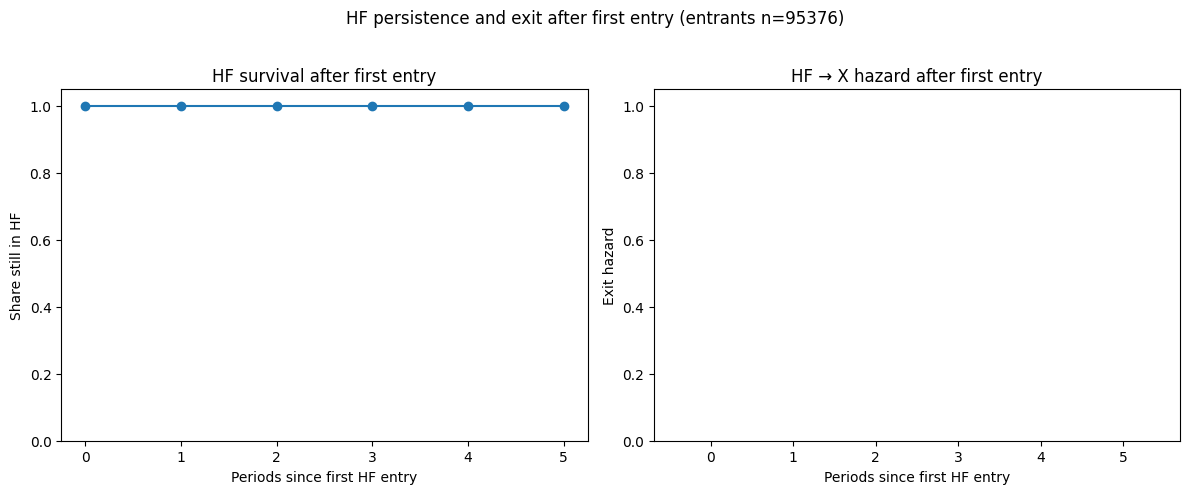

Event time: [0 1 2 3 4 5]
Survival in HF: [1. 1. 1. 1. 1. 1.]
Exit hazard: [0. 0. 0. 0. 0. 0.]
At risk: [95376 95376 95366 95270 94795 94026]


In [150]:
import numpy as np
import matplotlib.pyplot as plt

def hf_exit_event_study_from_sim_grid(
    sim_grid: list[dict],
    max_h: int | None = None,
    initial_prev_mode: str = "X",
):
    """
    Build event-time survival and hazard objects after first entry into HF,
    using the existing simulated paths.

    Event time h = 0 is the first period in which the firm is in HF.
    'Exit' means first downgrade from HF to X after that first entry.

    Returns a dictionary with:
      - event_h
      - survival_hf
      - exit_hazard
      - n_at_risk
      - n_observed
      - n_entrants
    """

    entrants = []

    for init_state in sim_grid:
        for path in init_state["paths"]:
            mode_path = path["mode_path"]

            # find first entry into HF
            first_entry_t = None
            for t, m in enumerate(mode_path):
                prev_m = initial_prev_mode if t == 0 else mode_path[t - 1]
                if (m == "HF") and (prev_m != "HF"):
                    first_entry_t = t
                    break

            if first_entry_t is None:
                continue

            entrants.append({
                "mode_path": mode_path,
                "entry_t": first_entry_t,
            })

    if len(entrants) == 0:
        raise ValueError("No firms enter HF in the current simulations.")

    # maximum feasible event horizon from the data
    max_feasible_h = max(len(e["mode_path"]) - 1 - e["entry_t"] for e in entrants)
    if max_h is None:
        max_h = max_feasible_h
    else:
        max_h = min(max_h, max_feasible_h)

    event_h = np.arange(0, max_h + 1)

    survival_hf = []
    exit_hazard = []
    n_at_risk = []
    n_observed = []

    for h in event_h:
        # Firms with at least h periods observed after entry
        observed_h = []
        for e in entrants:
            if e["entry_t"] + h < len(e["mode_path"]):
                observed_h.append(e)

        n_observed.append(len(observed_h))

        # Survival: still HF through event time h
        survived_h = []
        for e in observed_h:
            subpath = e["mode_path"][e["entry_t"] : e["entry_t"] + h + 1]
            survived = all(m == "HF" for m in subpath)
            survived_h.append(survived)

        survival_hf.append(np.mean(survived_h) if len(survived_h) > 0 else np.nan)

        # Hazard: first downgrade occurs exactly at h
        # Only defined for h >= 1
        if h == 0:
            exit_hazard.append(0.0)
            n_at_risk.append(len(observed_h))
        else:
            at_risk_h = []
            first_exit_at_h = []

            for e in observed_h:
                subpath_prev = e["mode_path"][e["entry_t"] : e["entry_t"] + h]
                subpath_now = e["mode_path"][e["entry_t"] : e["entry_t"] + h + 1]

                # At risk means survived HF through h-1
                survived_to_h_minus_1 = all(m == "HF" for m in subpath_prev)
                if survived_to_h_minus_1:
                    at_risk_h.append(e)

                    # First exit at h means still HF through h-1, then X at h
                    first_exit_now = (subpath_now[-1] == "X")
                    first_exit_at_h.append(first_exit_now)

            n_at_risk.append(len(at_risk_h))
            exit_hazard.append(
                np.mean(first_exit_at_h) if len(first_exit_at_h) > 0 else np.nan
            )

    return {
        "event_h": event_h,
        "survival_hf": np.array(survival_hf, dtype=float),
        "exit_hazard": np.array(exit_hazard, dtype=float),
        "n_at_risk": np.array(n_at_risk, dtype=int),
        "n_observed": np.array(n_observed, dtype=int),
        "n_entrants": len(entrants),
    }


def plot_hf_exit_rate(event_stats: dict) -> None:
    """
    Plot survival in HF and exit hazard after first HF entry.
    """
    h = event_stats["event_h"]
    S = event_stats["survival_hf"]
    hazard = event_stats["exit_hazard"]
    n_entrants = event_stats["n_entrants"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

    # Survival curve
    axes[0].plot(h, S, marker="o")
    axes[0].set_xlabel("Periods since first HF entry")
    axes[0].set_ylabel("Share still in HF")
    axes[0].set_title("HF survival after first entry")
    axes[0].set_ylim(0, 1.05)

    # Exit hazard
    axes[1].bar(h, hazard)
    axes[1].set_xlabel("Periods since first HF entry")
    axes[1].set_ylabel("Exit hazard")
    axes[1].set_title("HF → X hazard after first entry")
    axes[1].set_ylim(0, 1.05)

    fig.suptitle(f"HF persistence and exit after first entry (entrants n={n_entrants})", y=1.02)
    plt.tight_layout()
    plt.show()


# Run
hf_exit_stats = hf_exit_event_study_from_sim_grid(sim_grid, max_h=5, initial_prev_mode="X")
plot_hf_exit_rate(hf_exit_stats)

print("Event time:", hf_exit_stats["event_h"])
print("Survival in HF:", np.round(hf_exit_stats["survival_hf"], 3))
print("Exit hazard:", np.round(hf_exit_stats["exit_hazard"], 3))
print("At risk:", hf_exit_stats["n_at_risk"])